In [1]:
import numpy as np
from tqdm import tqdm, trange
from brian2 import *
import matplotlib.pyplot as plt
from sheet_attractor import simulator
from util import *
from fit import *
from visualization import create_3d_animation
FIG_PATH = 'figures/'
os.makedirs(FIG_PATH, exist_ok=True)


INFO       Cache size for target 'cython': 1250 MB.
You can call clear_cache('cython') to delete all files from the cache or manually delete files in the '/home/pajucg/.cython/brian_extensions' directory. [brian2]


# Simulation parameters

In [2]:
parameters = {'w_EE': 0.72, 'w_EI': 0.14, 'w_IE': 0.74, 'w_II': 0.01, 'w_EP': 0.01, 'w_PE': 0.71, 'w_PP': 0.01, 'sigma': 0.0001}


In [3]:
parameters = {
  "w_EE": 0.72,
  "w_EI": 0.143, # 0.143
  "w_IE": 0.76, # 0.74
  "w_II": 0.01, # 0.01
  "w_PP": 0.01,
  "w_EP": 0.013, # 0.012
  "w_PE": 0.71, # .709
  "sigma": 0.001,
}

# events = [
#         {'type': 'visual_cue_on', 'x': 2, 'y': 6, 'strength': 0.5, 'duration': 300*ms},
#         {'type': 'visual_cue_off', 'duration': 300*ms},
#         {'type': 'shift', 'direction': 'right', 'strength': conf['shifter_strength'], 'duration': 1100*ms},
#         {'type': 'shift', 'direction': 'up', 'strength': conf['shifter_strength'], 'duration': 1100*ms},
#         {'type': 'shift', 'direction': 'left', 'strength': conf['shifter_strength'], 'duration': 1100*ms},
#         {'type': 'shift', 'direction': 'down', 'strength': conf['shifter_strength'], 'duration': 1100*ms},
#     ]

events = [
        {'type': 'visual_cue_on', 'x': 2, 'y': 6, 'strength': 0.5, 'duration': 300*ms},
        {'type': 'visual_cue_off', 'duration': 300*ms},
        {'type': 'shift', 'direction': 'right', 'strength': 0.018, 'duration': 2000*ms},
        {'type': 'run', 'duration': 100*ms},
        {'type': 'shift', 'direction': 'up', 'strength': 0.018, 'duration': 2000*ms},
    ]



21:58:16 : 0 min 1.5 sec -> simulation start
22:02:45 : 4 min 30.2 sec -> simulation end
47000


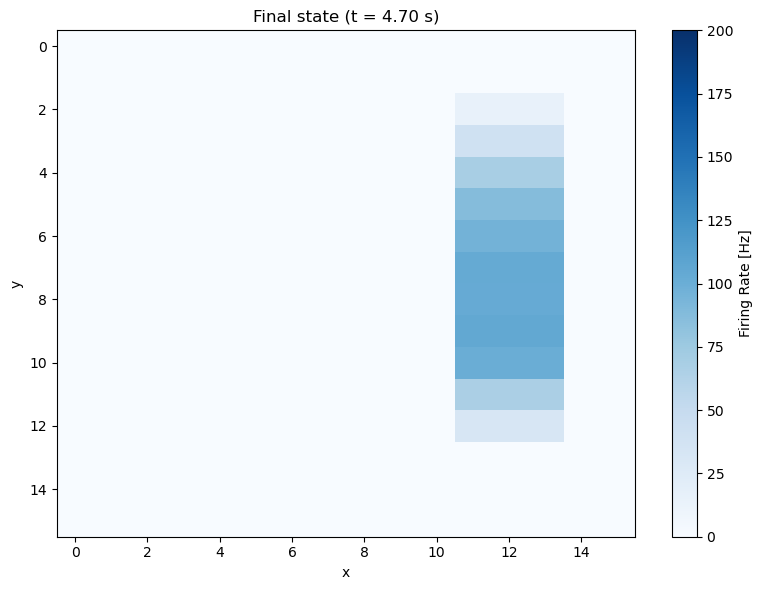

In [4]:
results = simulator(w_EE = parameters['w_EE'], # EB <-> EB
                    w_EI = parameters['w_EI'], # EPG -> R # 0.15
                    w_IE = parameters['w_IE'], # R -> EPG
                    w_II = parameters['w_II'], # R <-> R
                    w_PP = parameters['w_PP'], # PEN <-> PEN
                    w_EP = parameters['w_EP'], # EB -> PEN 
                    w_PE = parameters['w_PE'], # PEN -> EB
                    sigma = parameters['sigma'], # noise level
                    
                    events = events,
                    defaultclock_dt=0.1 # ms
                                    )
t, fr, fr_penx, fr_peny = results
print(len(t))

processed_data = process_data(fr)
# Plot the last frame
plt.figure(figsize=(8, 6))
last_frame = processed_data[:, :, -1]
im_last = plt.imshow(last_frame, cmap='Blues', aspect='auto', interpolation='none',
                     vmin=0, vmax=200)
plt.colorbar(im_last, label='Firing Rate [Hz]')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Final state (t = {(processed_data.shape[2]-1)/10000:.2f} s)')
plt.tight_layout()
plt.show()

# Activity Heatmap

In [14]:
# Create and show the 3D animation
processed_data = process_data(fr)
fig = create_3d_animation(fr_penx)
fig.show()
fig = create_3d_animation(fr_peny)
fig.show()
fig = create_3d_animation(processed_data)
fig.show()


# Trajectory

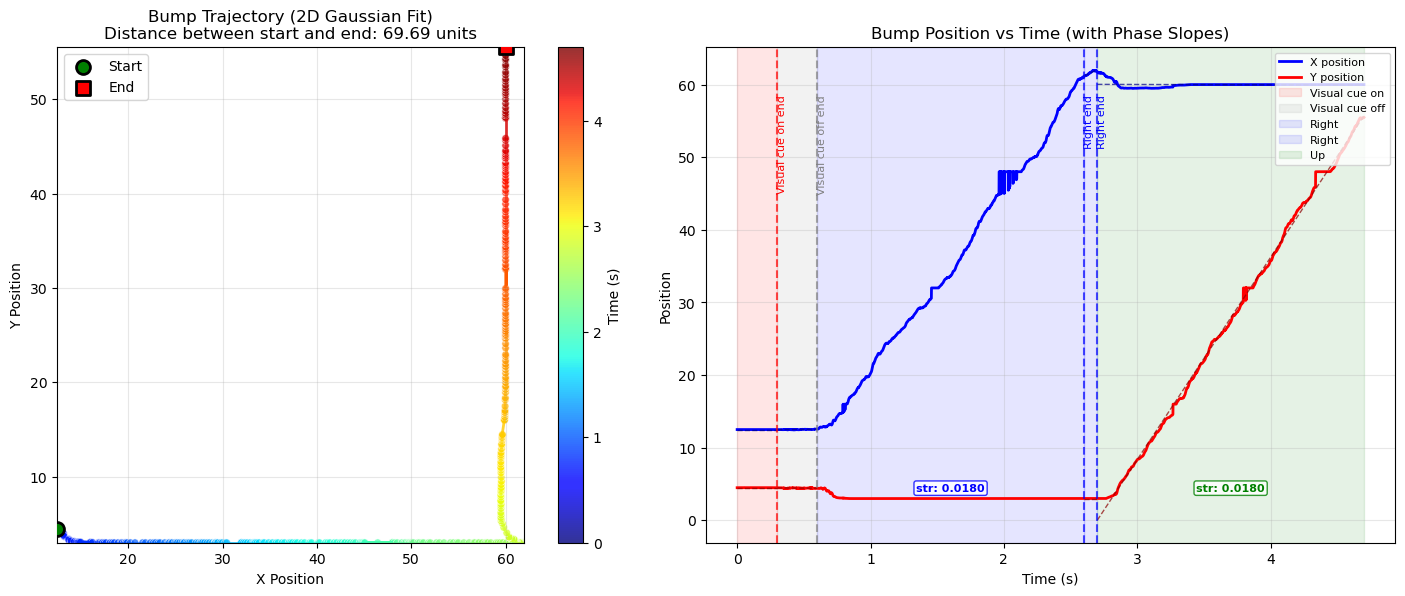

In [7]:
from fit import analyze_trajectory, bump_position
# Call the function with the required parameters
processed_data = process_data(fr)
bump_positions, fit_params = bump_position(processed_data)
trajectory_results = analyze_trajectory(bump_positions, fit_params, processed_data, events)

In [10]:
import plotly.graph_objects as go
import numpy as np

# Extract bump positions
bump_positions = trajectory_results['bump_positions']
time_points = trajectory_results['time_points']

# Create the 3D plot
fig = go.Figure()

# Plot the trajectory with time as z-axis
fig.add_trace(go.Scatter3d(
    x=bump_positions[:, 0],
    y=bump_positions[:, 1],
    z=time_points,
    mode='lines',
    line=dict(color='blue', width=4),
    name='Trajectory',
    opacity=0.7
))

# Mark start and end points
fig.add_trace(go.Scatter3d(
    x=[bump_positions[0, 0]],
    y=[bump_positions[0, 1]],
    z=[time_points[0]],
    mode='markers',
    marker=dict(color='green', size=8, symbol='circle'),
    name='Start'
))

fig.add_trace(go.Scatter3d(
    x=[bump_positions[-1, 0]],
    y=[bump_positions[-1, 1]],
    z=[time_points[-1]],
    mode='markers',
    marker=dict(color='red', size=8, symbol='square'),
    name='End'
))

# Add some trajectory points for better visualization
n_points = 20
point_indices = np.linspace(0, len(bump_positions)-1, n_points, dtype=int)
fig.add_trace(go.Scatter3d(
    x=bump_positions[point_indices, 0],
    y=bump_positions[point_indices, 1],
    z=time_points[point_indices],
    mode='markers',
    marker=dict(
        color=time_points[point_indices],
        colorscale='viridis',
        size=4,
        opacity=0.6,
        colorbar=dict(title="Time")
    ),
    name='Trajectory Points'
))

fig.update_layout(
    scene=dict(
        xaxis_title='X Position',
        yaxis_title='Y Position',
        zaxis_title='Time'
    ),
    title='3D Bump Trajectory (X-Y-Time)',
    width=240,
    height=200
)

fig.show()


# 10 trials

In [ ]:
break

In [ ]:
from tqdm import tqdm, trange
from multiprocessing import Pool
import multiprocessing as mp
import random

parameters = {
  "w_EE": 0.72,
  "w_EI": 0.143, # 0.143
  "w_IE": 0.76, # 0.74
  "w_II": 0.01, # 0.01
  "w_PP": 0.01,
  "w_EP": 0.013, # 0.012
  "w_PE": 0.71, # .709
  "sigma": 0.001,
}

events = [
        {'type': 'visual_cue_on', 'x': 2, 'y': 6, 'strength': 0.5, 'duration': 300*ms},
        {'type': 'visual_cue_off', 'duration': 300*ms},
        {'type': 'shift', 'direction': 'right', 'strength': 0.018, 'duration': 2000*ms},
        {'type': 'run', 'duration': 100*ms},
        {'type': 'shift', 'direction': 'up', 'strength': 0.018, 'duration': 2000*ms},
    ]


def run_single_simulation(seed):
    """
    Run a single simulation with a given random seed
    
    Args:
        seed (int): Random seed for the simulation
    
    Returns:
        tuple: (speed, bump_positions) from the simulation
    """
    t, fr, fr_penx, fr_peny = simulator(w_EE = parameters['w_EE'], # EB <-> EB
                    w_EI = parameters['w_EI'], # EPG -> R # 0.15
                    w_IE = parameters['w_IE'], # R -> EPG
                    w_II = parameters['w_II'], # R <-> R
                    w_PP = parameters['w_PP'], # PEN <-> PEN
                    w_EP = parameters['w_EP'], # EB -> PEN 
                    w_PE = parameters['w_PE'], # PEN -> EB
                    sigma = parameters['sigma'], # noise level
                    
                    events = events,
                    defaultclock_dt=0.1,
                    seed=seed)

    processed_data = process_data(fr)
    bp, fit_params = bump_position(processed_data)
    trajectory_results = analyze_trajectory(bp, fit_params, processed_data, events)
    direction = events[2]['direction'].capitalize() 
    speed = trajectory_results['phase_results'][direction]['speed']
    bump_pos = trajectory_results['bump_positions']
    return speed, bump_pos


def run_multiple_simulations(parameters, events, num_simulations=10, n_processes=None):
    """
    Run multiple simulations with different random seeds and collect results using parallel computation
    
    Args:
        parameters (dict): Parameters for the simulation
        events (list): List of events for the simulation
        num_simulations (int): Number of simulations to run
        n_processes (int): Number of processes to use. If None, uses all available CPUs
    
    Returns:
        tuple: (speeds, bump_positions) lists from all simulations
    """ 
    if n_processes is None:
        n_processes = mp.cpu_count()
    
    print(f"Running {num_simulations} simulations using {n_processes} processes")
    
    # Create list of seeds for each simulation
    seeds = list(range(num_simulations))
    
    # Run simulations in parallel
    with Pool(processes=n_processes) as pool:
        results = list(tqdm(
            pool.imap(run_single_simulation, seeds),
            total=num_simulations,
            desc="Running simulations"
        ))
    
    # Separate speeds and bump_positions
    speeds = [result[0] for result in results]
    bump_positions = [result[1] for result in results]
    
    return speeds, bump_positions

speeds, bump_positions = run_multiple_simulations(parameters, events, num_simulations=10, n_processes=10)

Running 10 simulations using 10 processes


Running simulations:   0%|          | 0/10 [00:00<?, ?it/s]

22:03:54 : 0 min 1.8 sec -> simulation start
22:03:54 : 0 min 1.8 sec -> simulation start


22:03:54 : 0 min 1.8 sec -> simulation start
22:03:54 : 0 min 1.8 sec -> simulation start

22:03:54 : 0 min 1.8 sec -> simulation start
22:03:54 : 0 min 1.9 sec -> simulation start
22:03:54 : 0 min 1.9 sec -> simulation start


Running simulations:   0%|          | 0/10 [00:04<?, ?it/s]Process ForkPoolWorker-4:
Process ForkPoolWorker-6:
Process ForkPoolWorker-5:
Process ForkPoolWorker-2:
Process ForkPoolWorker-7:
Process ForkPoolWorker-9:
Process ForkPoolWorker-1:
Process ForkPoolWorker-10:
Process ForkPoolWorker-3:
Process ForkPoolWorker-8:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):



KeyboardInterrupt: 

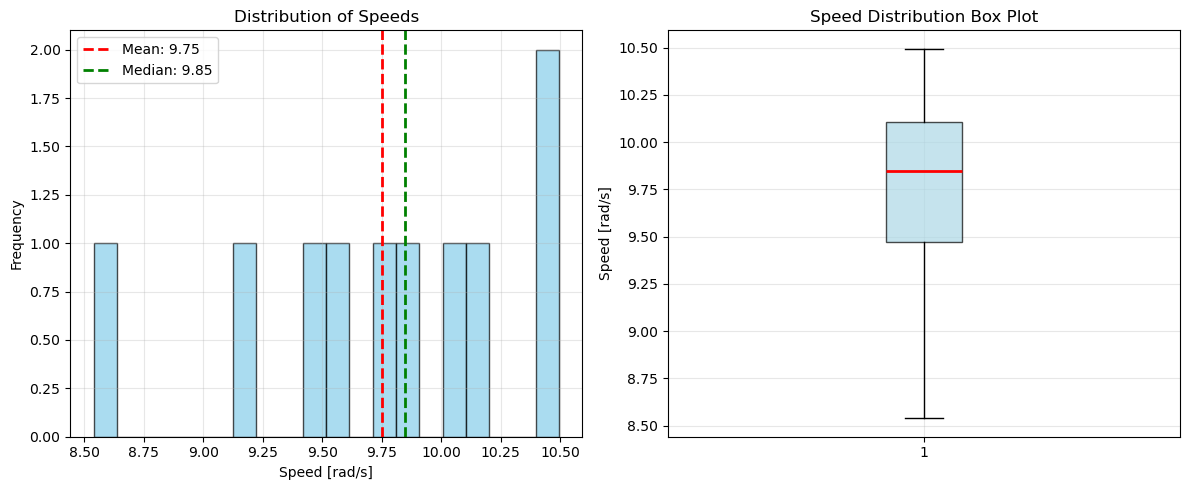

Speed Statistics:
Mean: 9.75 [rad/s]
Standard Deviation: 0.57 [rad/s]
Median: 9.85 [rad/s]
Min: 8.54 [rad/s]
Max: 10.49 [rad/s]



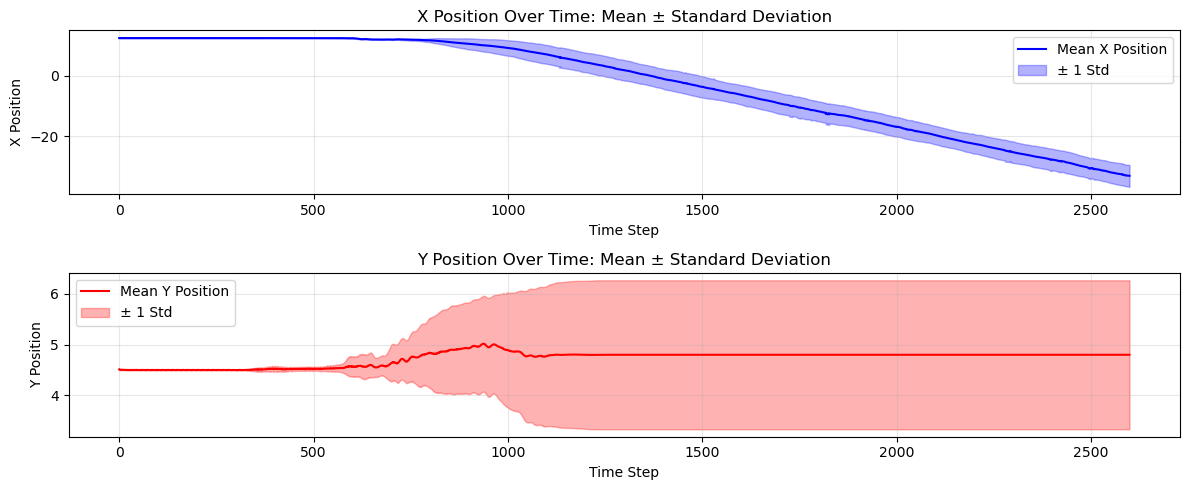

In [ ]:
# Calculate statistics for speeds
speeds_array = np.array(speeds)
speed_mean = np.mean(speeds_array)
speed_std = np.std(speeds_array)
speed_median = np.median(speeds_array)
speed_min = np.min(speeds_array)
speed_max = np.max(speeds_array)

# Plot speed statistics
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of speeds
ax1.hist(speeds_array * 2 * np.pi / 16, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(speed_mean * 2 * np.pi / 16, color='red', linestyle='--', linewidth=2, label=f'Mean: {speed_mean*2*np.pi/16:.2f}')
ax1.axvline(speed_median * 2 * np.pi / 16, color='green', linestyle='--', linewidth=2, label=f'Median: {speed_median*2*np.pi/16:.2f}')
ax1.set_xlabel('Speed [rad/s]')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Speeds')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot of speeds
ax2.boxplot(speeds_array * 2 * np.pi / 16, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Speed [rad/s]')
ax2.set_title('Speed Distribution Box Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Speed Statistics:")
print(f"Mean: {speed_mean*2*np.pi/16:.2f} [rad/s]")
print(f"Standard Deviation: {speed_std*2*np.pi/16:.2f} [rad/s]")
print(f"Median: {speed_median*2*np.pi/16:.2f} [rad/s]")
print(f"Min: {speed_min*2*np.pi/16:.2f} [rad/s]")
print(f"Max: {speed_max*2*np.pi/16:.2f} [rad/s]")
print()

pos_mean = np.mean(bump_positions, axis=0)
pos_std = np.std(bump_positions, axis=0)
pos_median = np.median(bump_positions, axis=0)
pos_min = np.min(bump_positions, axis=0)
pos_max = np.max(bump_positions, axis=0)
# print(pos_mean.shape)

import matplotlib.pyplot as plt

# Since pos_mean has shape (2600, 2), we need to handle the 2D position data
# Let's plot the trajectory of mean positions over time
time_steps = np.arange(pos_mean.shape[0])

# Create subplots for x and y positions
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))

# Plot x-position over time
ax1.plot(time_steps, pos_mean[:, 0], 'b-', label='Mean X Position')
ax1.fill_between(time_steps, 
                 pos_mean[:, 0] - pos_std[:, 0], 
                 pos_mean[:, 0] + pos_std[:, 0], 
                 alpha=0.3, color='blue', label='± 1 Std')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('X Position')
ax1.set_title('X Position Over Time: Mean ± Standard Deviation')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot y-position over time
ax2.plot(time_steps, pos_mean[:, 1], 'r-', label='Mean Y Position')
ax2.fill_between(time_steps, 
                 pos_mean[:, 1] - pos_std[:, 1], 
                 pos_mean[:, 1] + pos_std[:, 1], 
                 alpha=0.3, color='red', label='± 1 Std')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Y Position')
ax2.set_title('Y Position Over Time: Mean ± Standard Deviation')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




In [ ]:
from tqdm import tqdm, trange
from multiprocessing import Pool
import multiprocessing as mp
import random

parameters = {
  "w_EE": 0.72,
  "w_EI": 0.143, # 0.143
  "w_IE": 0.76, # 0.74
  "w_II": 0.01, # 0.01
  "w_PP": 0.01,
  "w_EP": 0.013, # 0.012
  "w_PE": 0.71, # .709
  "sigma": 0.001,
}

events = [
        {'type': 'visual_cue_on', 'x': 2, 'y': 6, 'strength': 0.5, 'duration': 300*ms},
        {'type': 'visual_cue_off', 'duration': 300*ms},
        {'type': 'shift', 'direction': 'up', 'strength': 0.018, 'duration': 2000*ms},
    ]


def run_single_simulation(seed):
    """
    Run a single simulation with a given random seed
    
    Args:
        seed (int): Random seed for the simulation
    
    Returns:
        tuple: (speed, bump_positions) from the simulation
    """
    t, fr, fr_penx, fr_peny = simulator(w_EE = parameters['w_EE'], # EB <-> EB
                    w_EI = parameters['w_EI'], # EPG -> R # 0.15
                    w_IE = parameters['w_IE'], # R -> EPG
                    w_II = parameters['w_II'], # R <-> R
                    w_PP = parameters['w_PP'], # PEN <-> PEN
                    w_EP = parameters['w_EP'], # EB -> PEN 
                    w_PE = parameters['w_PE'], # PEN -> EB
                    sigma = parameters['sigma'], # noise level
                    
                    events = events,
                    defaultclock_dt=0.1,
                    seed=seed)

    processed_data = process_data(fr)
    bp, fit_params = bump_position(processed_data)
    trajectory_results = analyze_trajectory(bp, fit_params, processed_data, events)
    direction = events[2]['direction'].capitalize() 
    speed = trajectory_results['phase_results'][direction]['speed']
    bump_pos = trajectory_results['bump_positions']
    return speed, bump_pos


def run_multiple_simulations(parameters, events, num_simulations=10, n_processes=None):
    """
    Run multiple simulations with different random seeds and collect results using parallel computation
    
    Args:
        parameters (dict): Parameters for the simulation
        events (list): List of events for the simulation
        num_simulations (int): Number of simulations to run
        n_processes (int): Number of processes to use. If None, uses all available CPUs
    
    Returns:
        tuple: (speeds, bump_positions) lists from all simulations
    """ 
    if n_processes is None:
        n_processes = mp.cpu_count()
    
    print(f"Running {num_simulations} simulations using {n_processes} processes")
    
    # Create list of seeds for each simulation
    seeds = list(range(num_simulations))
    
    # Run simulations in parallel
    with Pool(processes=n_processes) as pool:
        results = list(tqdm(
            pool.imap(run_single_simulation, seeds),
            total=num_simulations,
            desc="Running simulations"
        ))
    
    # Separate speeds and bump_positions
    speeds = [result[0] for result in results]
    bump_positions = [result[1] for result in results]
    
    return speeds, bump_positions

speeds, bump_positions = run_multiple_simulations(parameters, events, num_simulations=10, n_processes=10)

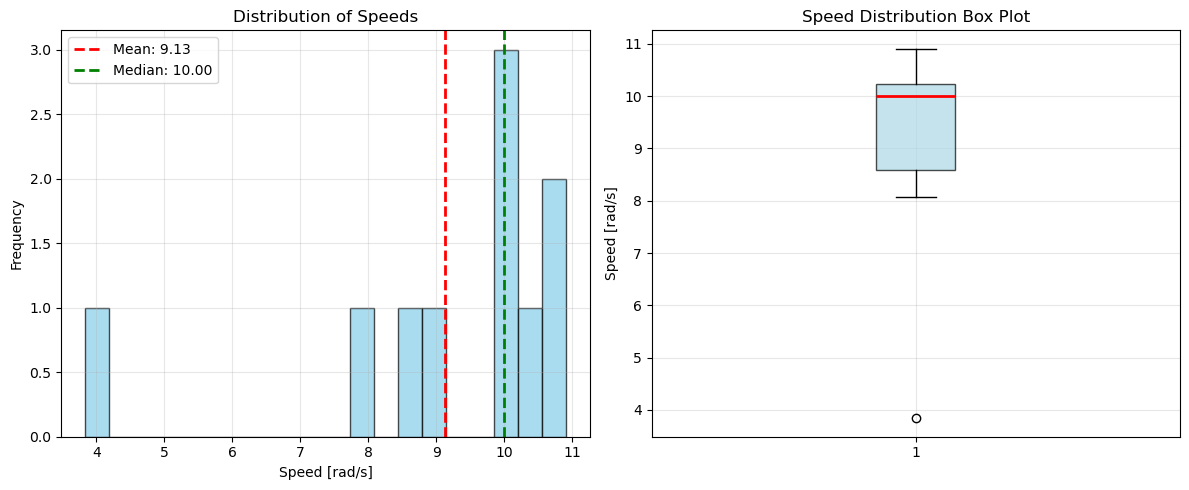

Speed Statistics:
Mean: 9.13 [rad/s]
Standard Deviation: 1.98 [rad/s]
Median: 10.00 [rad/s]
Min: 3.84 [rad/s]
Max: 10.91 [rad/s]



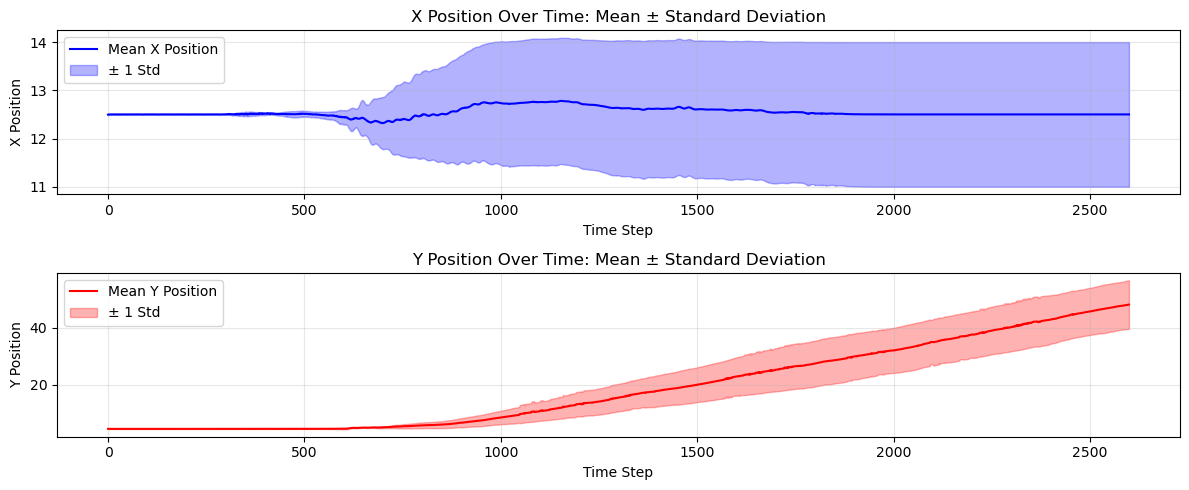

In [ ]:
# Calculate statistics for speeds
speeds_array = np.array(speeds)
speed_mean = np.mean(speeds_array)
speed_std = np.std(speeds_array)
speed_median = np.median(speeds_array)
speed_min = np.min(speeds_array)
speed_max = np.max(speeds_array)

# Plot speed statistics
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of speeds
ax1.hist(speeds_array * 2 * np.pi / 16, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(speed_mean * 2 * np.pi / 16, color='red', linestyle='--', linewidth=2, label=f'Mean: {speed_mean*2*np.pi/16:.2f}')
ax1.axvline(speed_median * 2 * np.pi / 16, color='green', linestyle='--', linewidth=2, label=f'Median: {speed_median*2*np.pi/16:.2f}')
ax1.set_xlabel('Speed [rad/s]')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Speeds')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot of speeds
ax2.boxplot(speeds_array * 2 * np.pi / 16, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Speed [rad/s]')
ax2.set_title('Speed Distribution Box Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Speed Statistics:")
print(f"Mean: {speed_mean*2*np.pi/16:.2f} [rad/s]")
print(f"Standard Deviation: {speed_std*2*np.pi/16:.2f} [rad/s]")
print(f"Median: {speed_median*2*np.pi/16:.2f} [rad/s]")
print(f"Min: {speed_min*2*np.pi/16:.2f} [rad/s]")
print(f"Max: {speed_max*2*np.pi/16:.2f} [rad/s]")
print()

pos_mean = np.mean(bump_positions, axis=0)
pos_std = np.std(bump_positions, axis=0)
pos_median = np.median(bump_positions, axis=0)
pos_min = np.min(bump_positions, axis=0)
pos_max = np.max(bump_positions, axis=0)
# print(pos_mean.shape)

import matplotlib.pyplot as plt

# Since pos_mean has shape (2600, 2), we need to handle the 2D position data
# Let's plot the trajectory of mean positions over time
time_steps = np.arange(pos_mean.shape[0])

# Create subplots for x and y positions
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))

# Plot x-position over time
ax1.plot(time_steps, pos_mean[:, 0], 'b-', label='Mean X Position')
ax1.fill_between(time_steps, 
                 pos_mean[:, 0] - pos_std[:, 0], 
                 pos_mean[:, 0] + pos_std[:, 0], 
                 alpha=0.3, color='blue', label='± 1 Std')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('X Position')
ax1.set_title('X Position Over Time: Mean ± Standard Deviation')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot y-position over time
ax2.plot(time_steps, pos_mean[:, 1], 'r-', label='Mean Y Position')
ax2.fill_between(time_steps, 
                 pos_mean[:, 1] - pos_std[:, 1], 
                 pos_mean[:, 1] + pos_std[:, 1], 
                 alpha=0.3, color='red', label='± 1 Std')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Y Position')
ax2.set_title('Y Position Over Time: Mean ± Standard Deviation')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




# vary shifter strenght

In [11]:
import numpy as np
from tqdm import tqdm, trange
from brian2 import *
import matplotlib.pyplot as plt
from sheet_attractor import simulator
from util import *
from fit import *

FIG_PATH = 'figures/'
os.makedirs(FIG_PATH, exist_ok=True)

Running 30 simulations using 25 processes
22:08:11 : 0 min 1.6 sec -> simulation start
22:08:11 : 0 min 1.6 sec -> simulation start
22:08:11 : 0 min 1.6 sec -> simulation start
22:08:11 : 0 min 1.6 sec -> simulation start

22:08:11 : 0 min 1.6 sec -> simulation start
22:08:11 : 0 min 1.7 sec -> simulation start
22:08:12 : 0 min 2.3 sec -> simulation start
22:08:12 : 0 min 2.3 sec -> simulation start
22:08:12 : 0 min 2.3 sec -> simulation start
22:08:12 : 0 min 2.7 sec -> simulation start



22:08:12 : 0 min 2.7 sec -> simulation start

22:08:12 : 0 min 2.7 sec -> simulation start
22:08:12 : 0 min 2.7 sec -> simulation start

22:08:12 : 0 min 2.7 sec -> simulation start

22:08:12 : 0 min 2.7 sec -> simulation start

22:08:12 : 0 min 2.7 sec -> simulation start
22:08:12 : 0 min 2.7 sec -> simulation start
22:12:31 : 4 min 21.4 sec -> simulation end
22:12:32 : 4 min 22.4 sec -> simulation end
22:12:34 : 4 min 24.0 sec -> simulation end
22:12:34 : 4 min 24.2 sec -> simulation end
22:12:35 

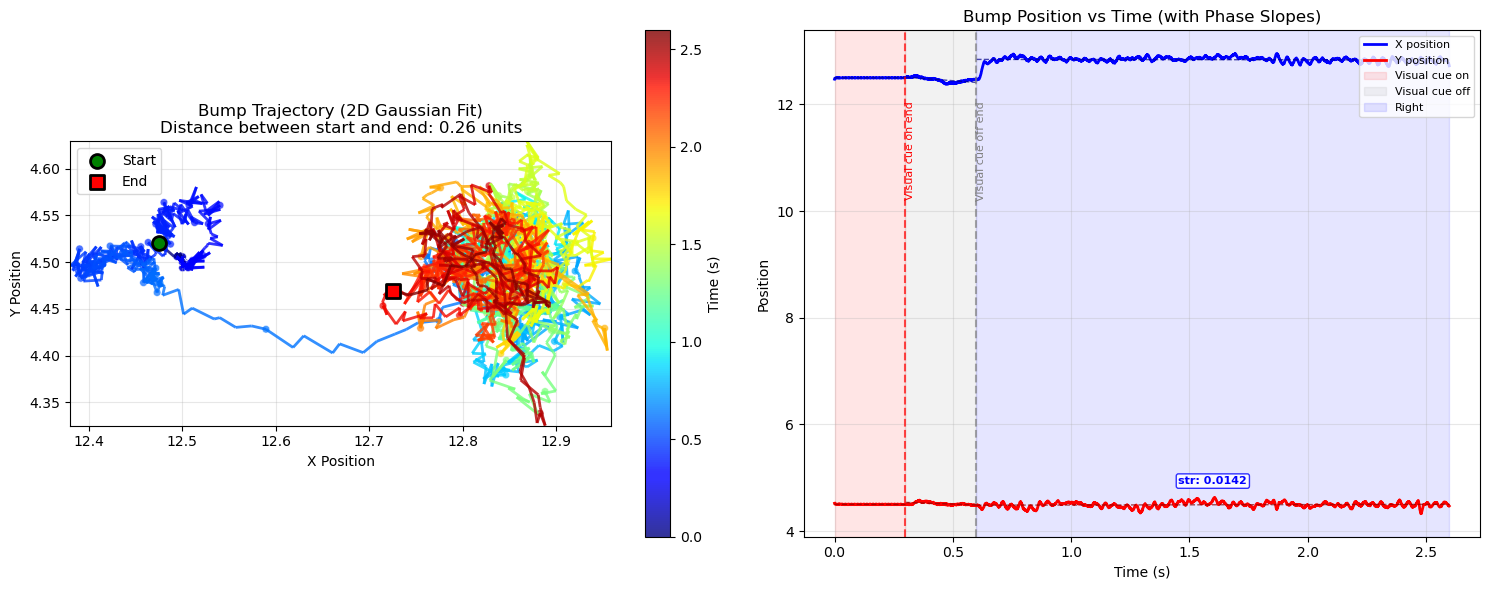

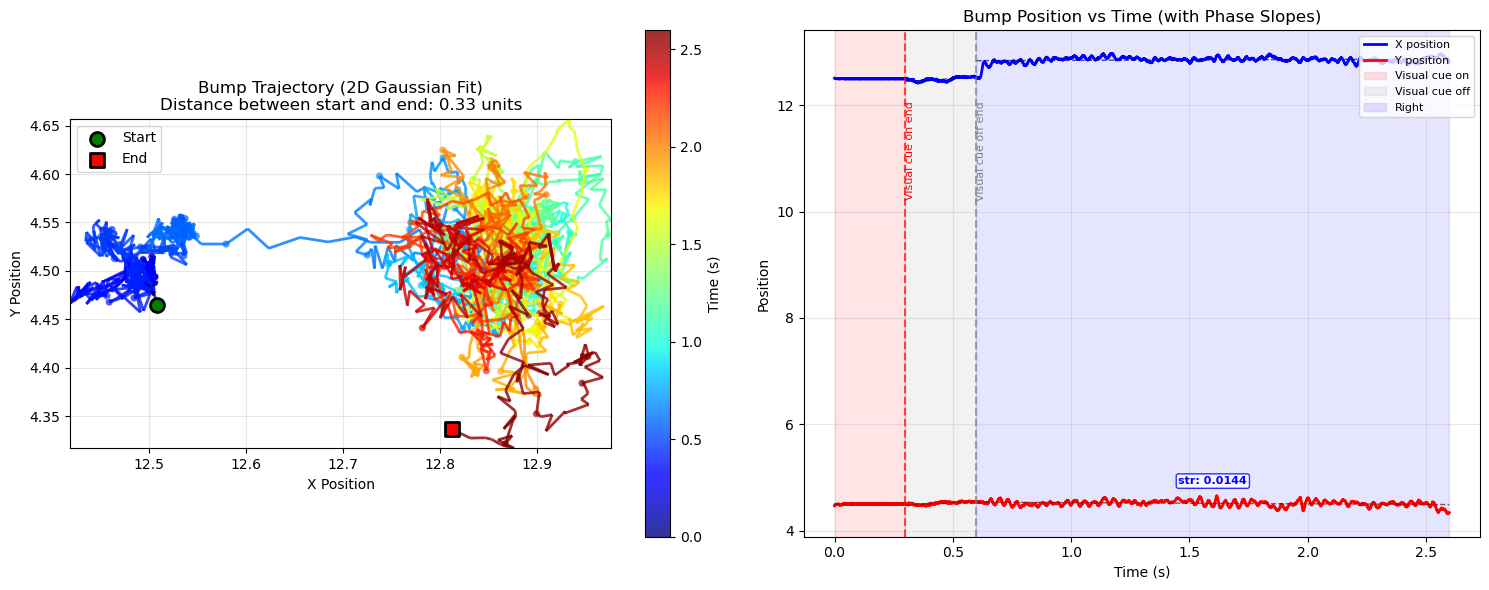

22:17:06 : 0 min 35.4 sec -> simulation start
22:17:26 : 0 min 35.8 sec -> simulation start


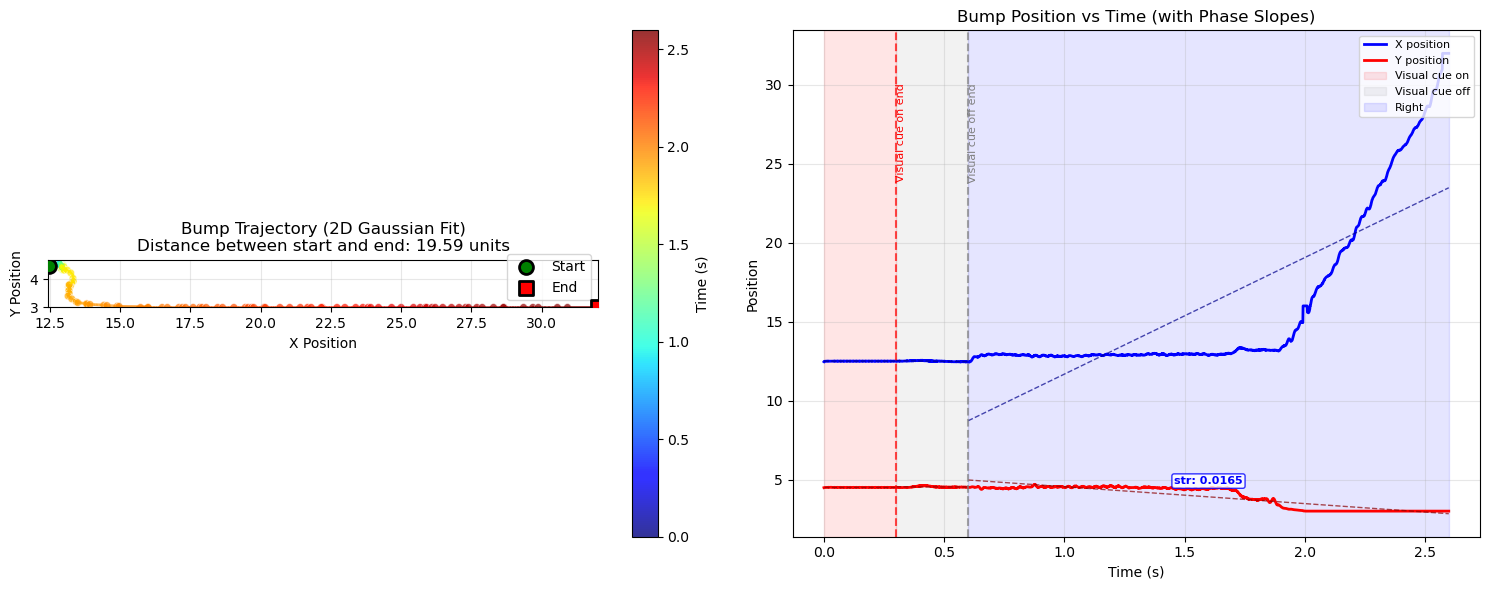

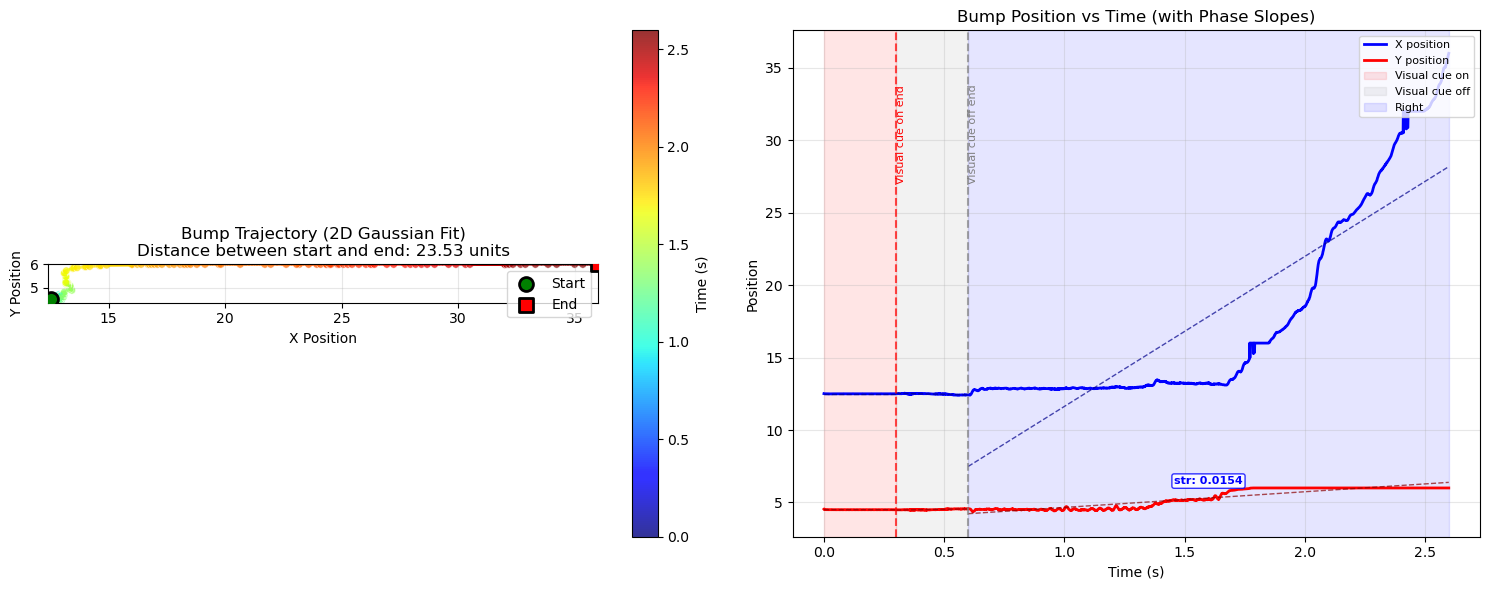

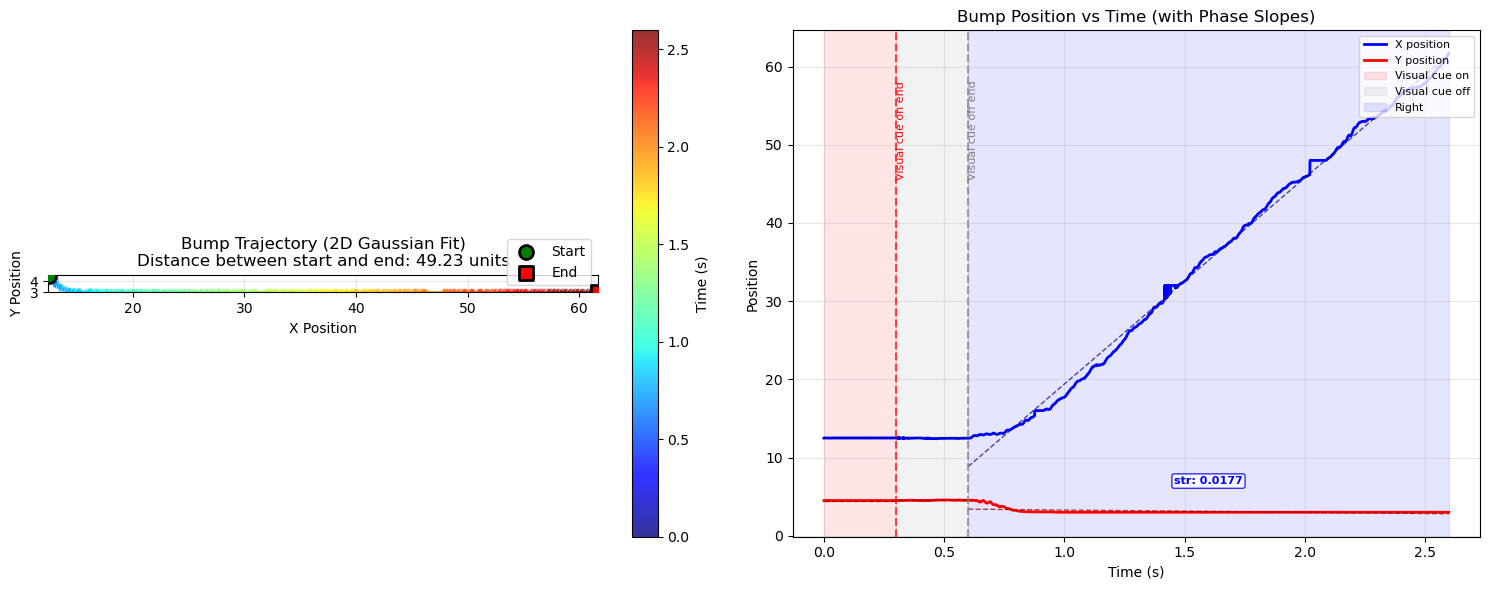

22:18:04 : 0 min 33.0 sec -> simulation start
22:18:13 : 0 min 34.4 sec -> simulation start


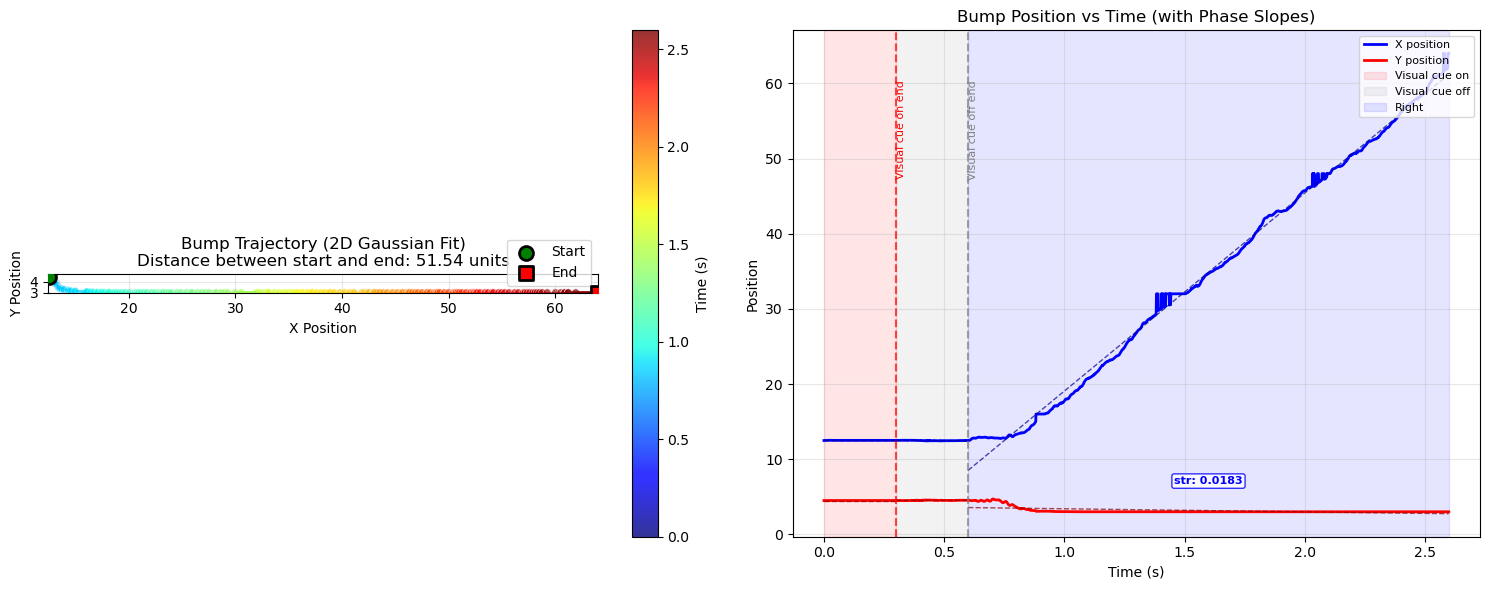

22:18:31 : 0 min 33.2 sec -> simulation start


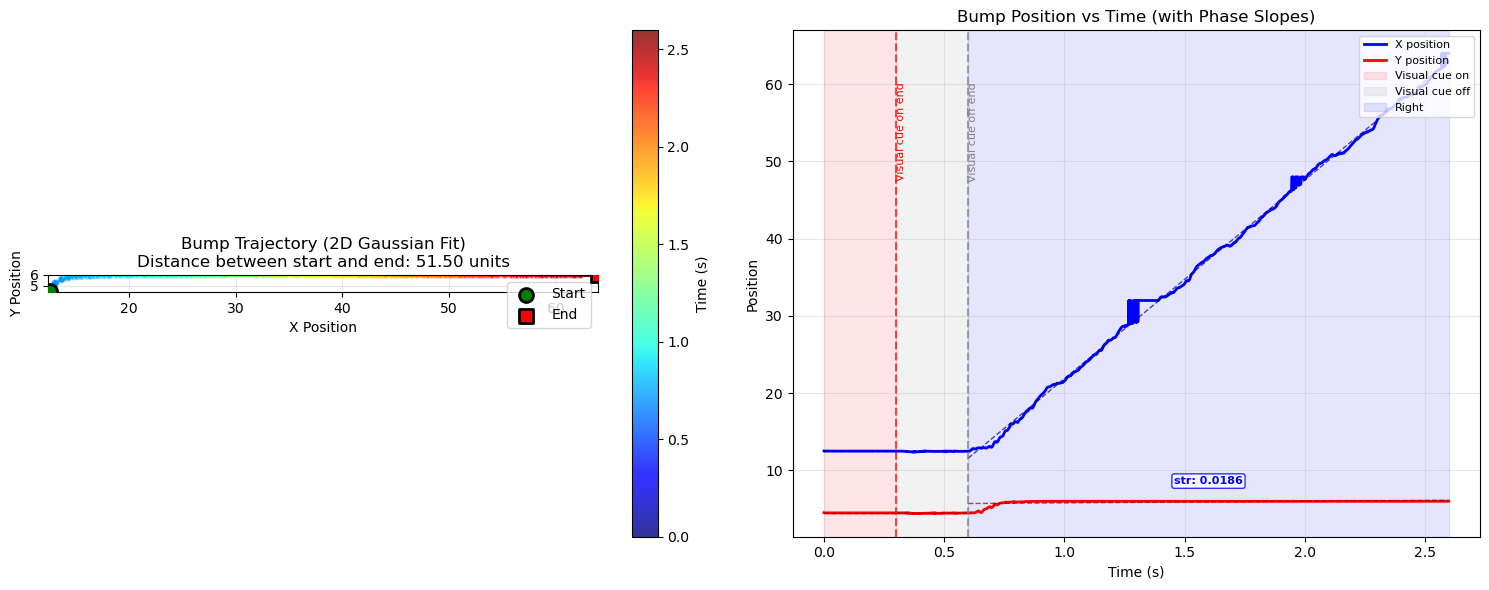

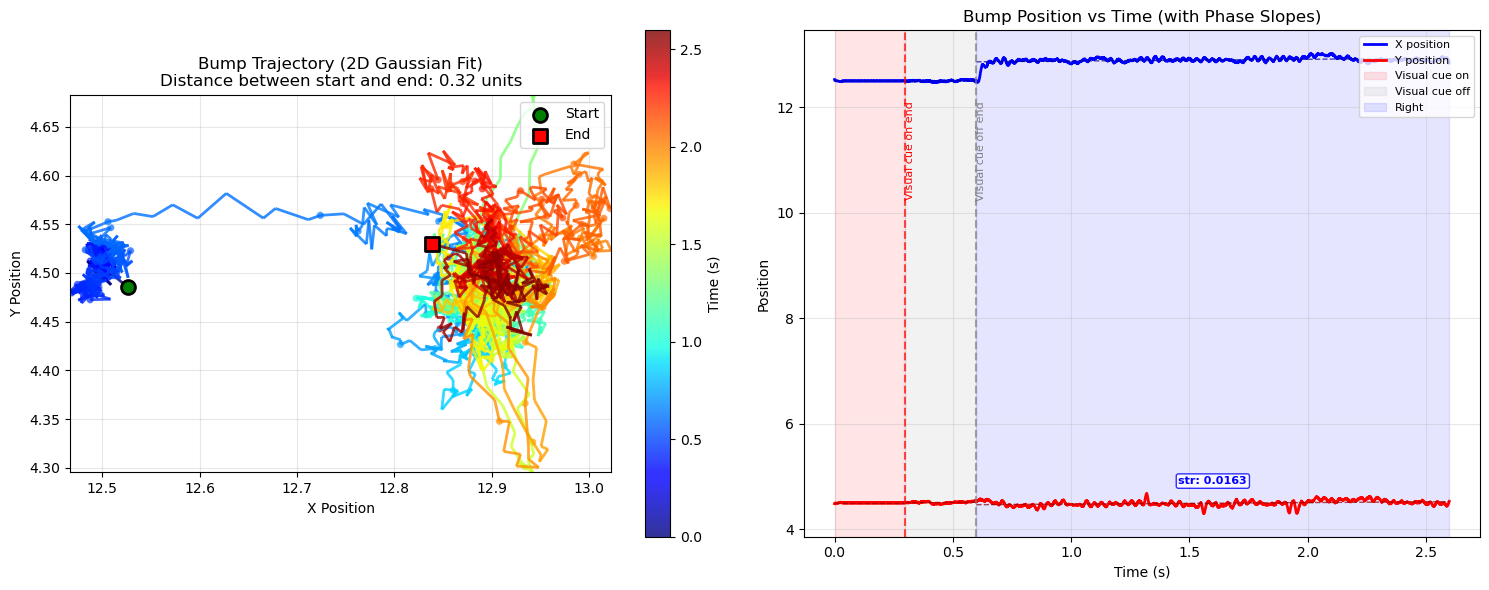

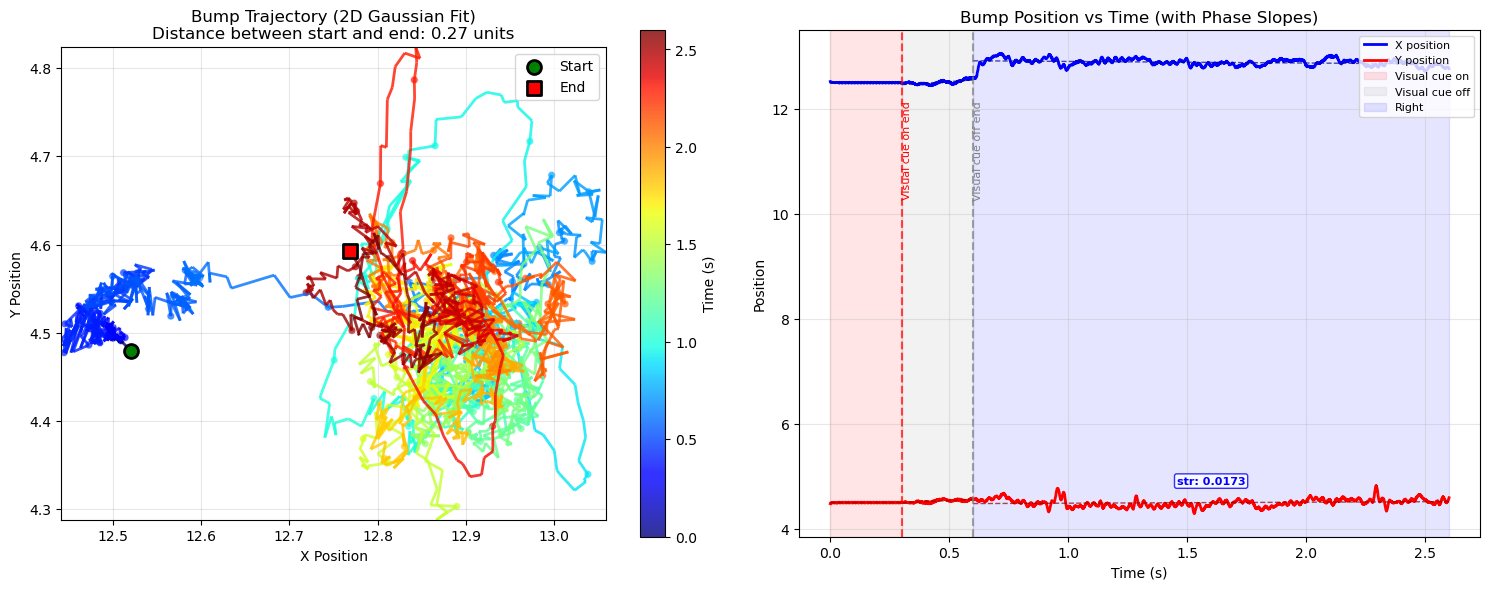

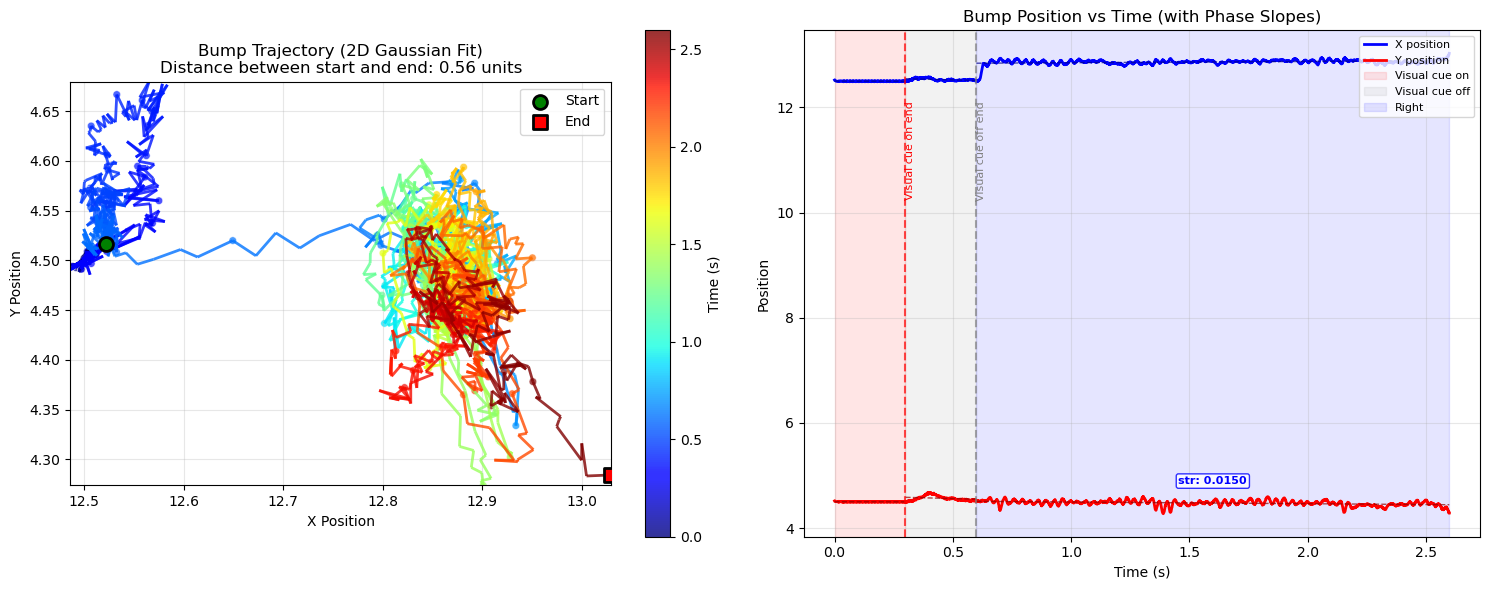

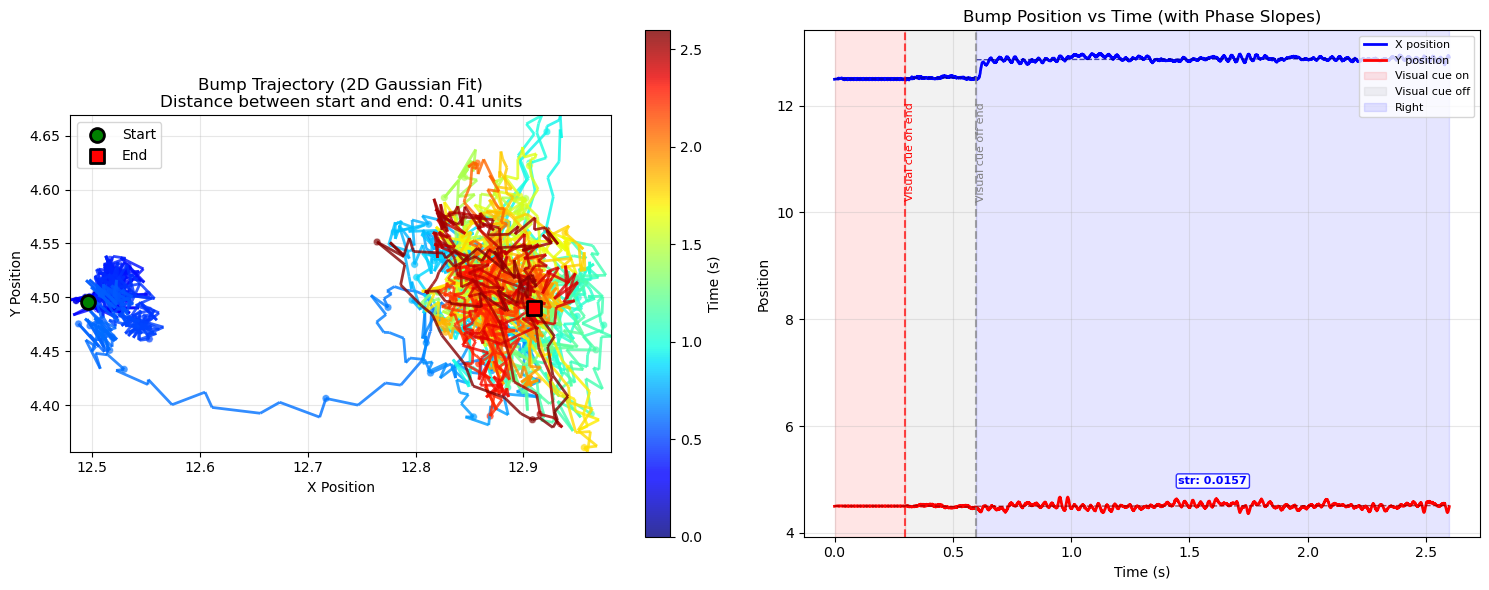

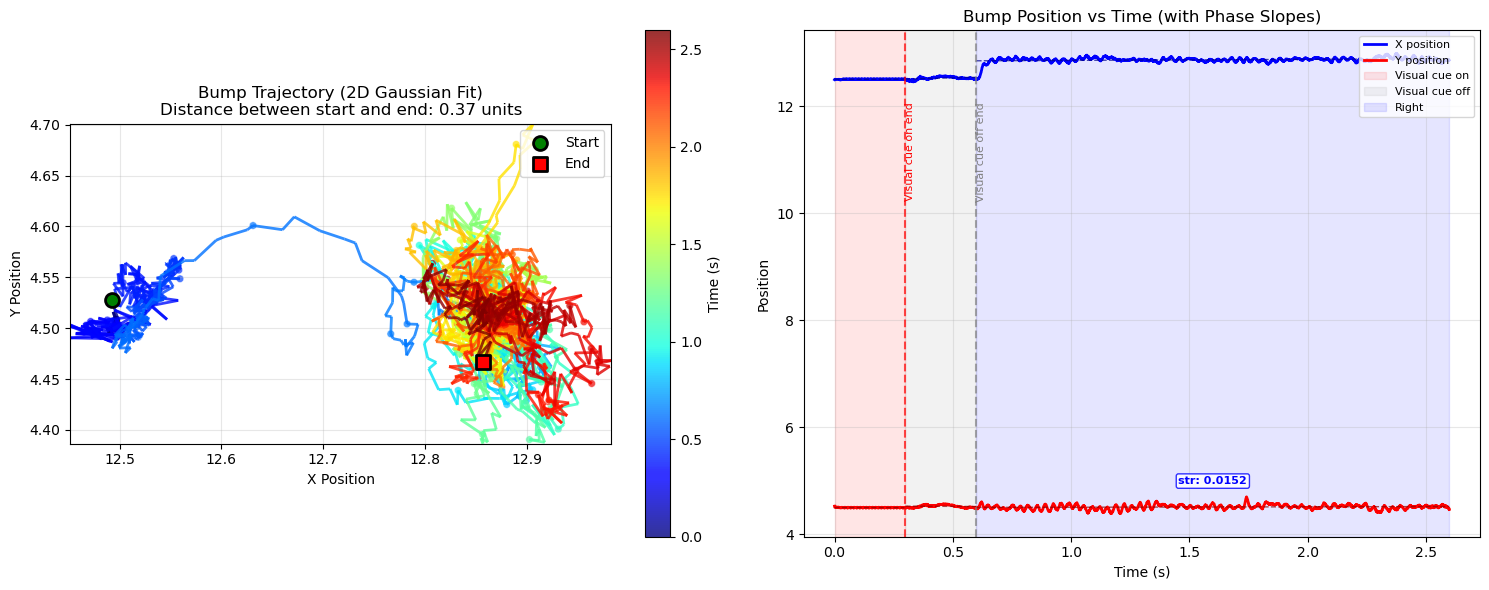

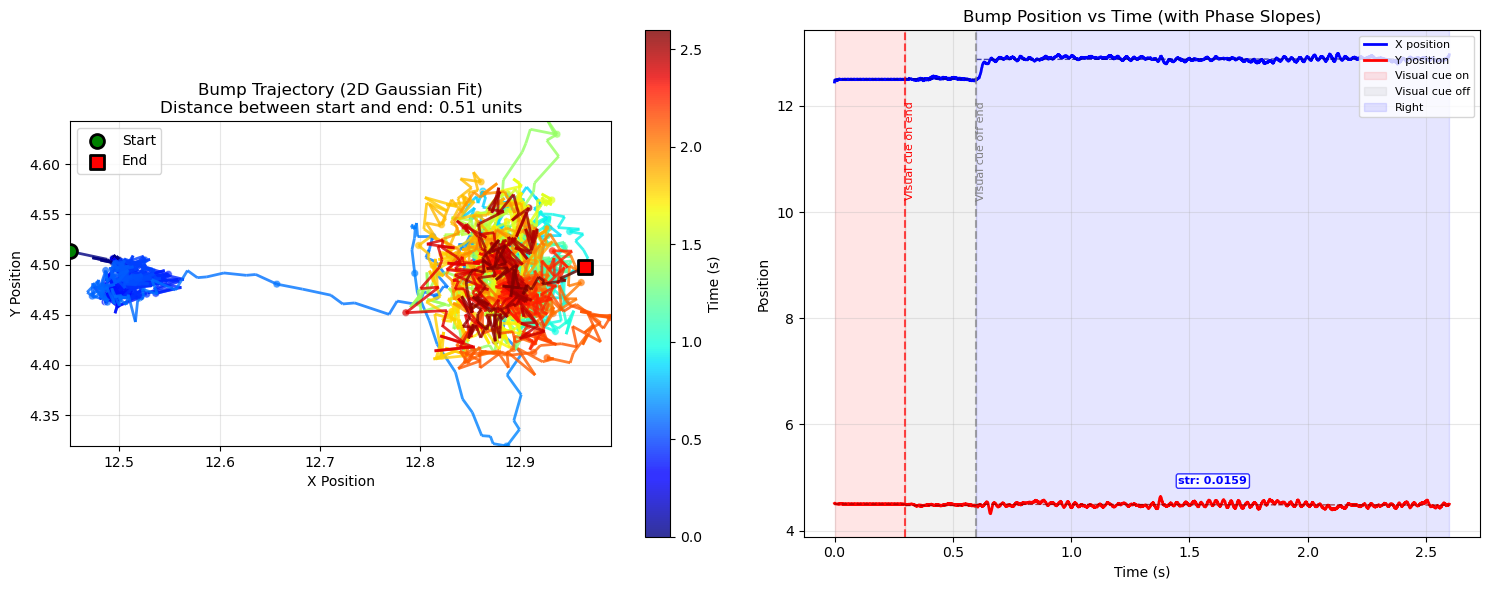

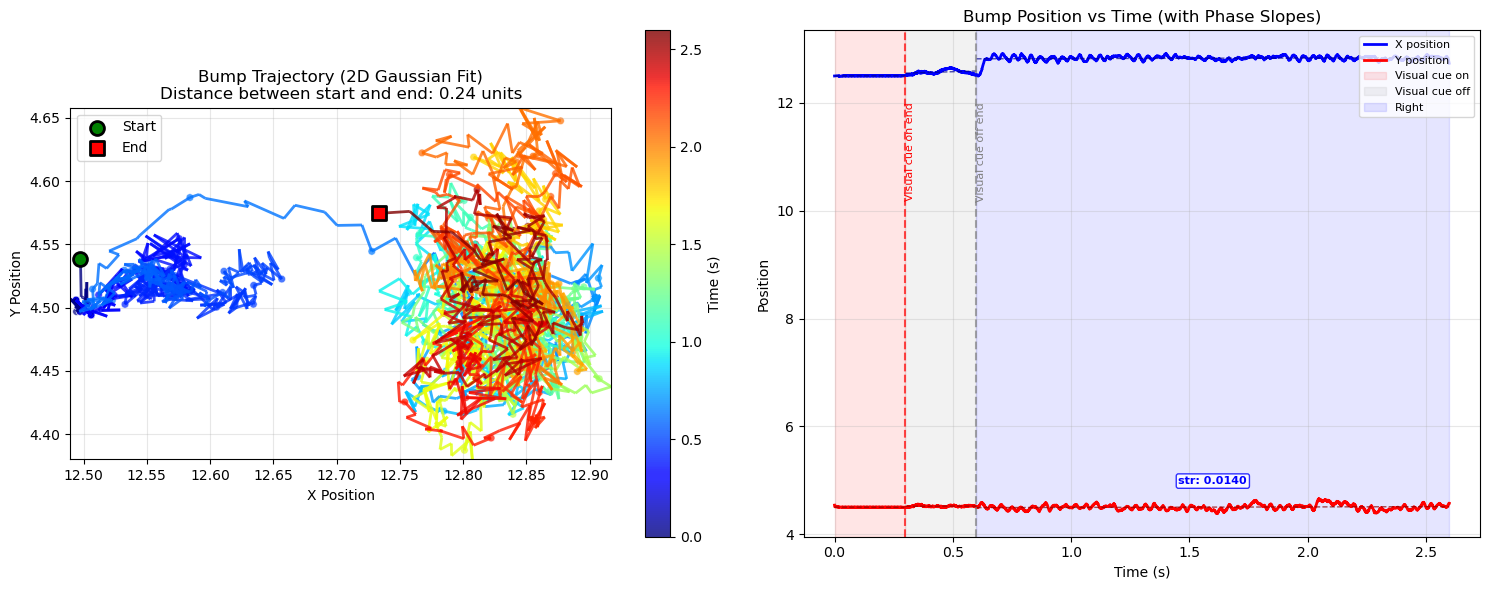

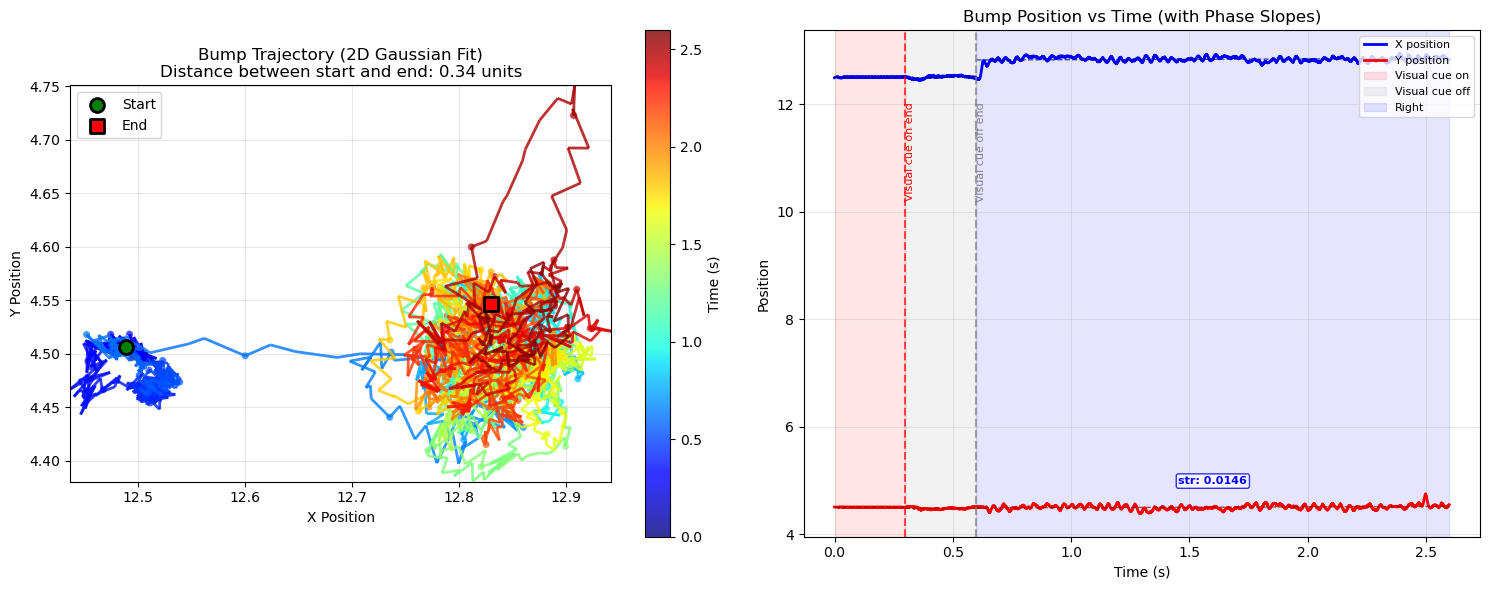

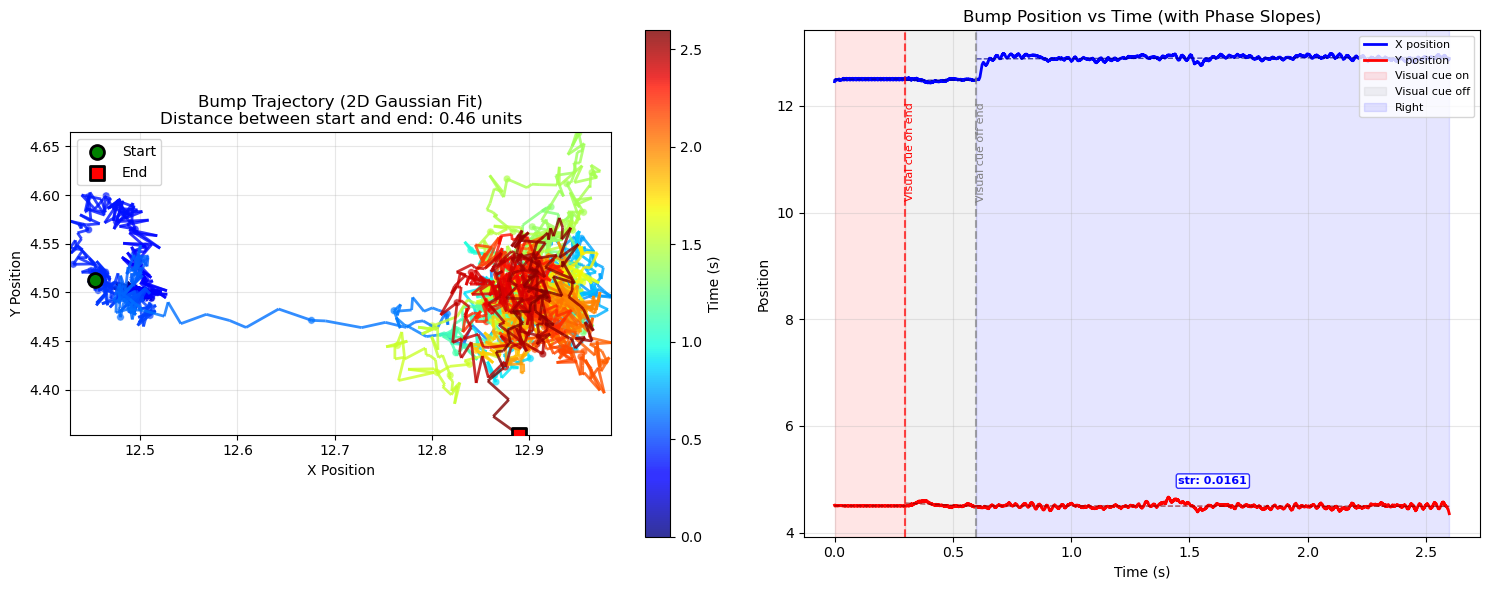

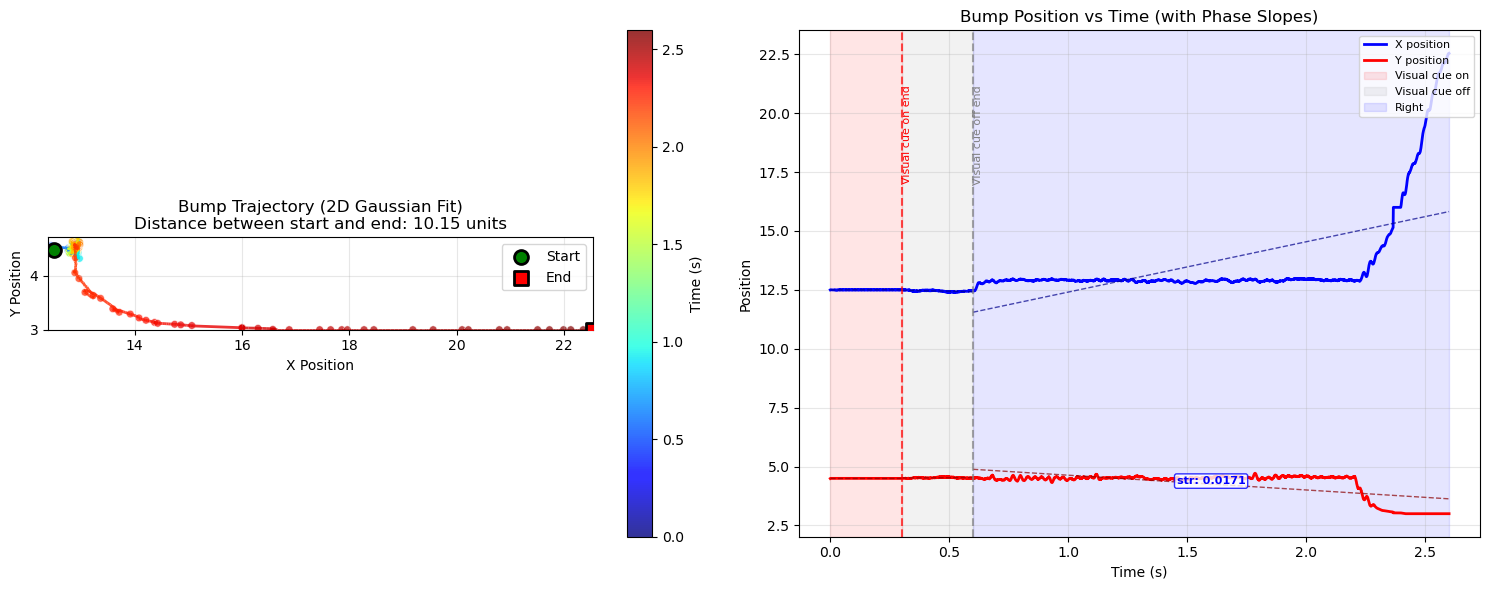

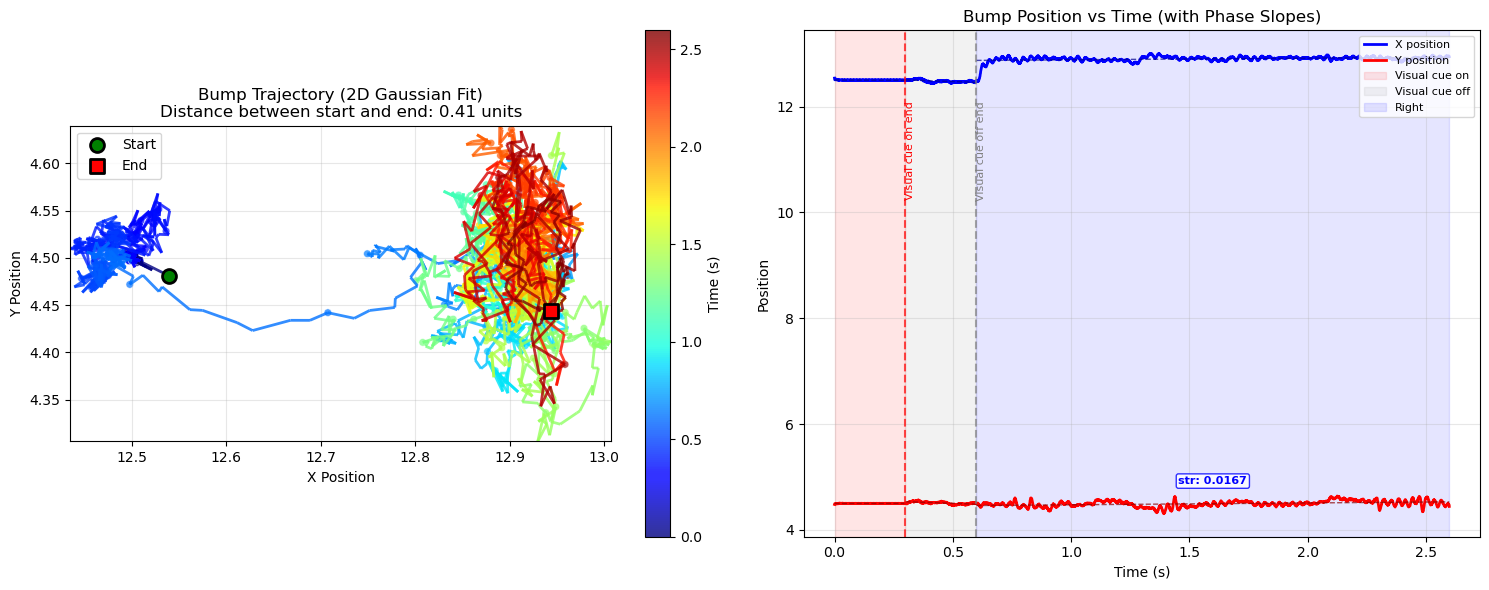

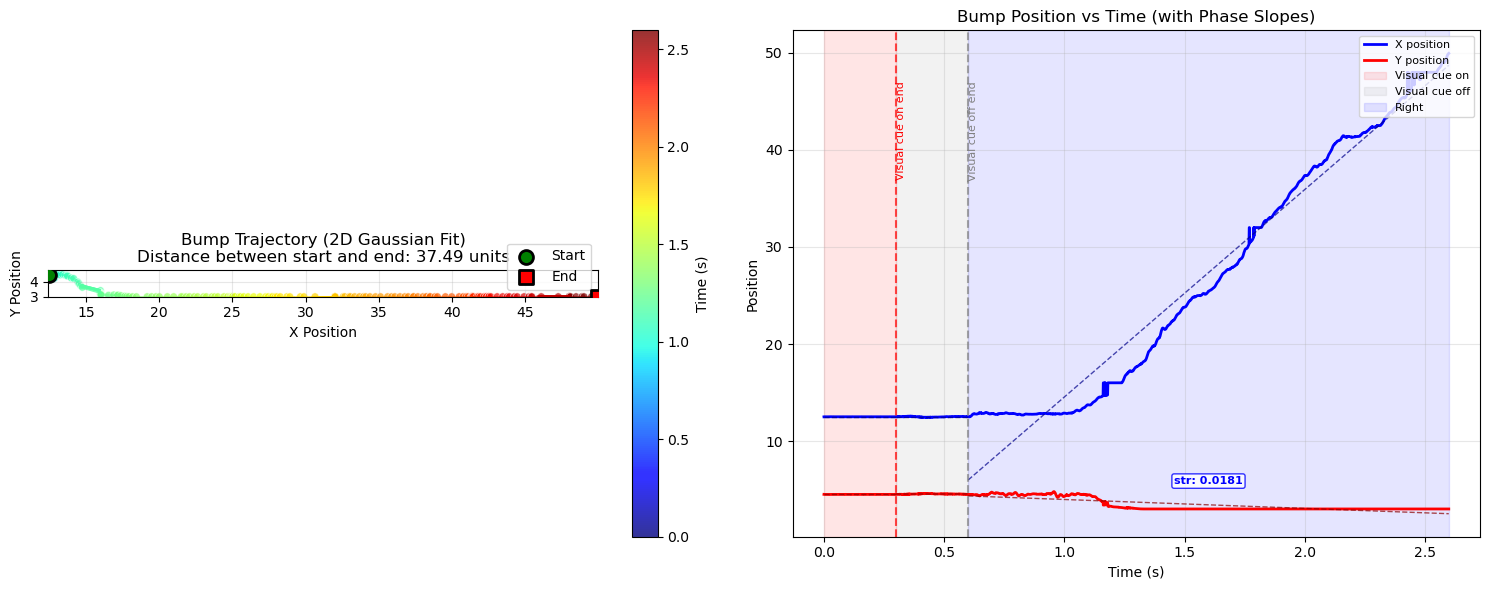

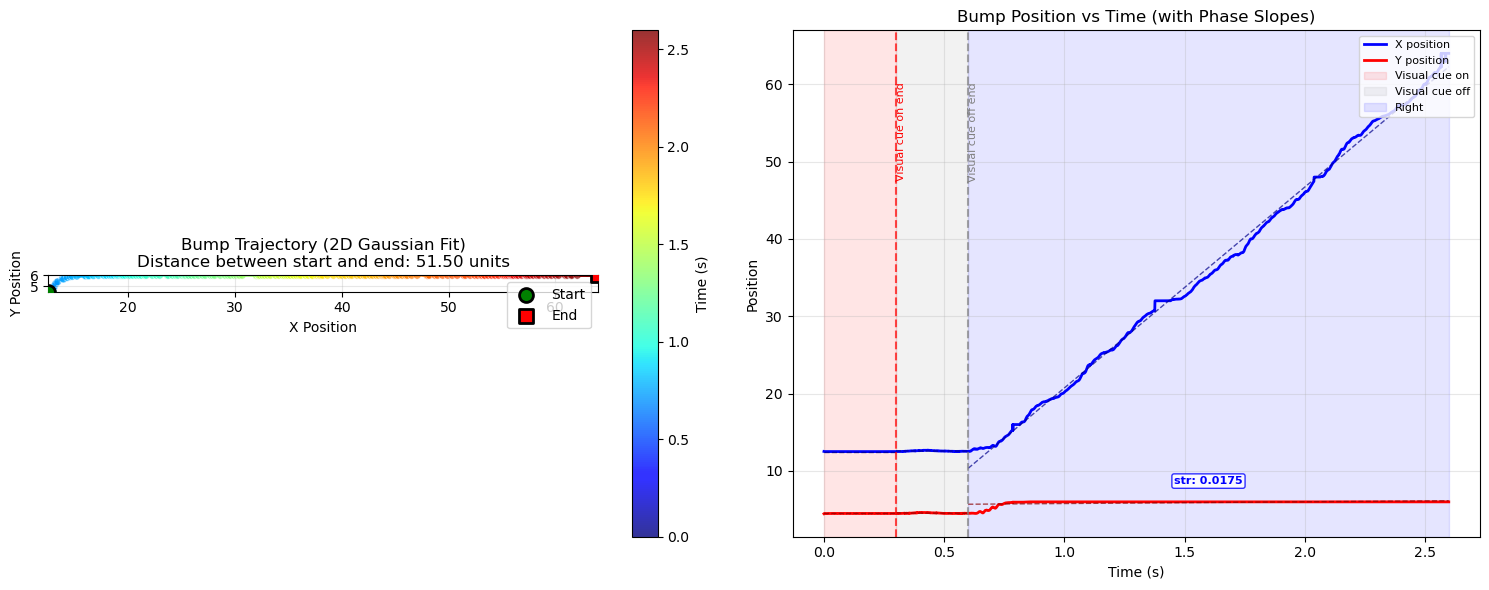

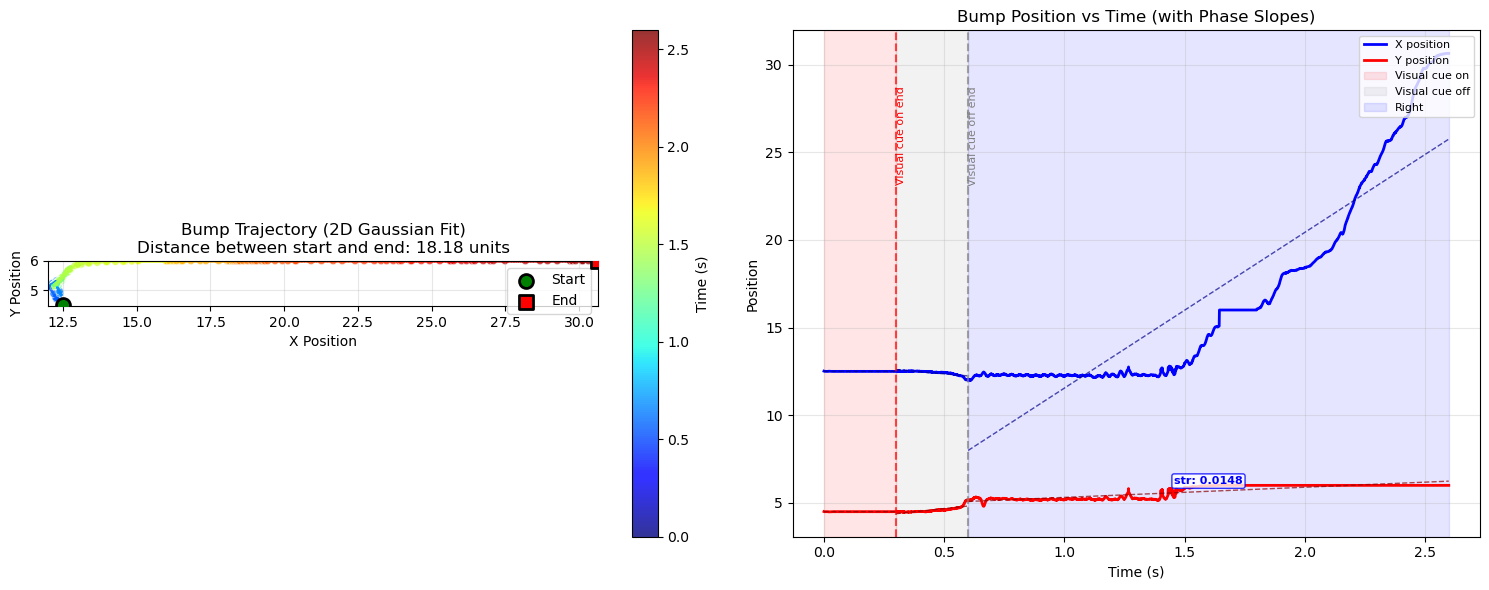

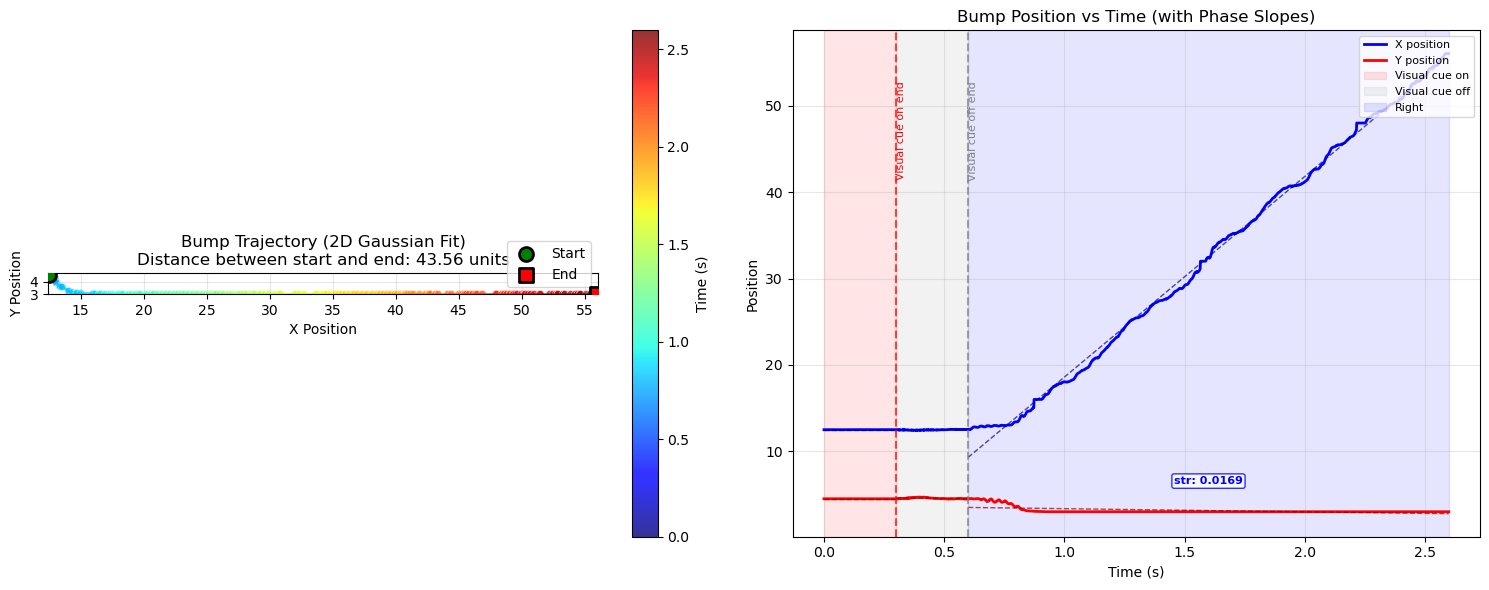

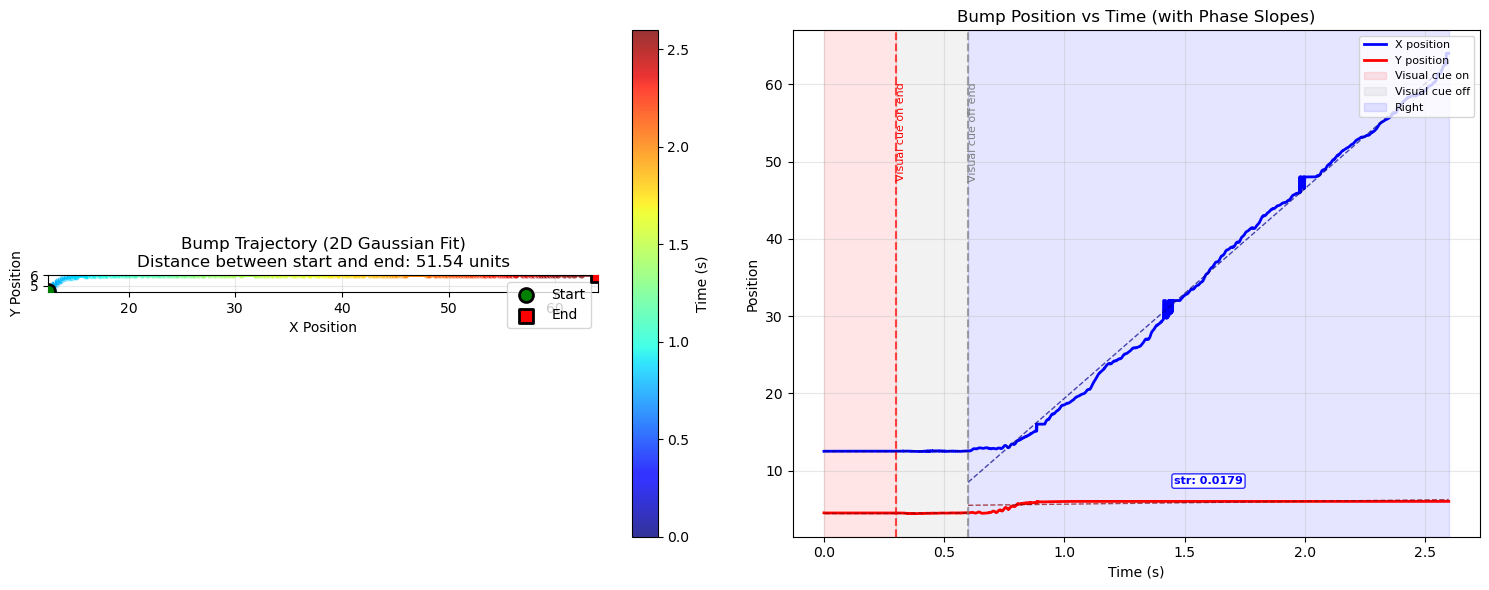

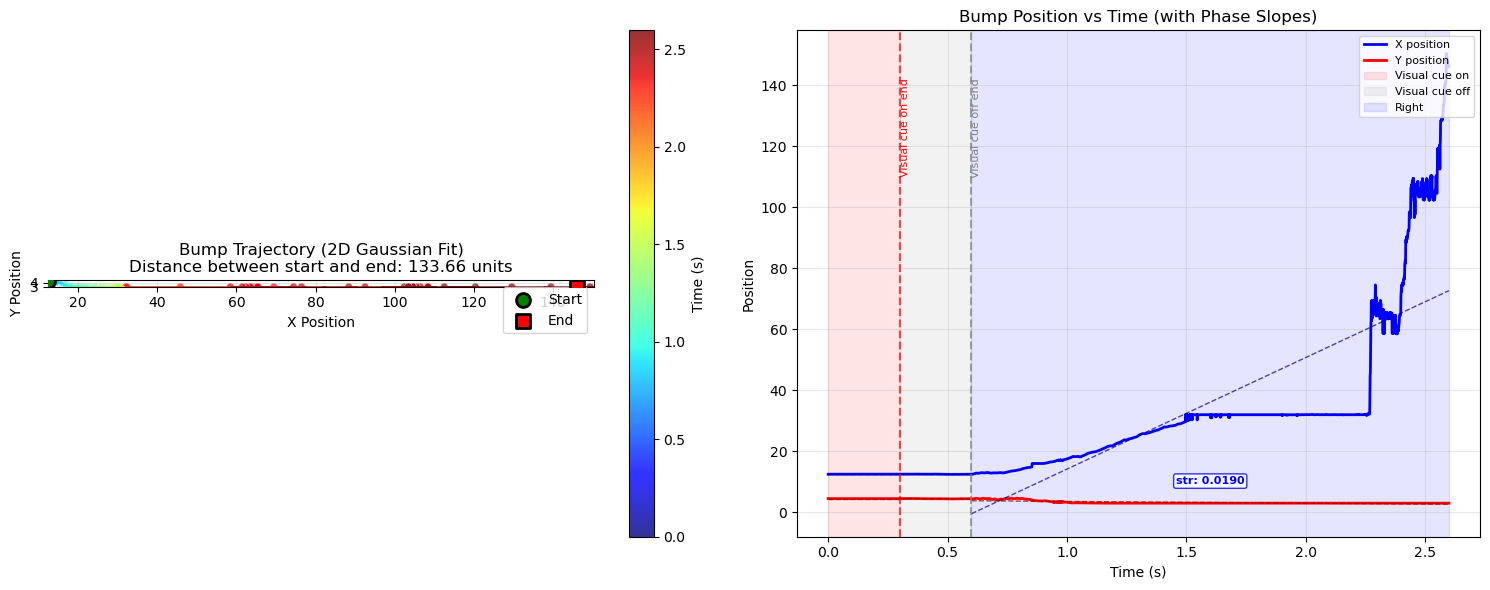

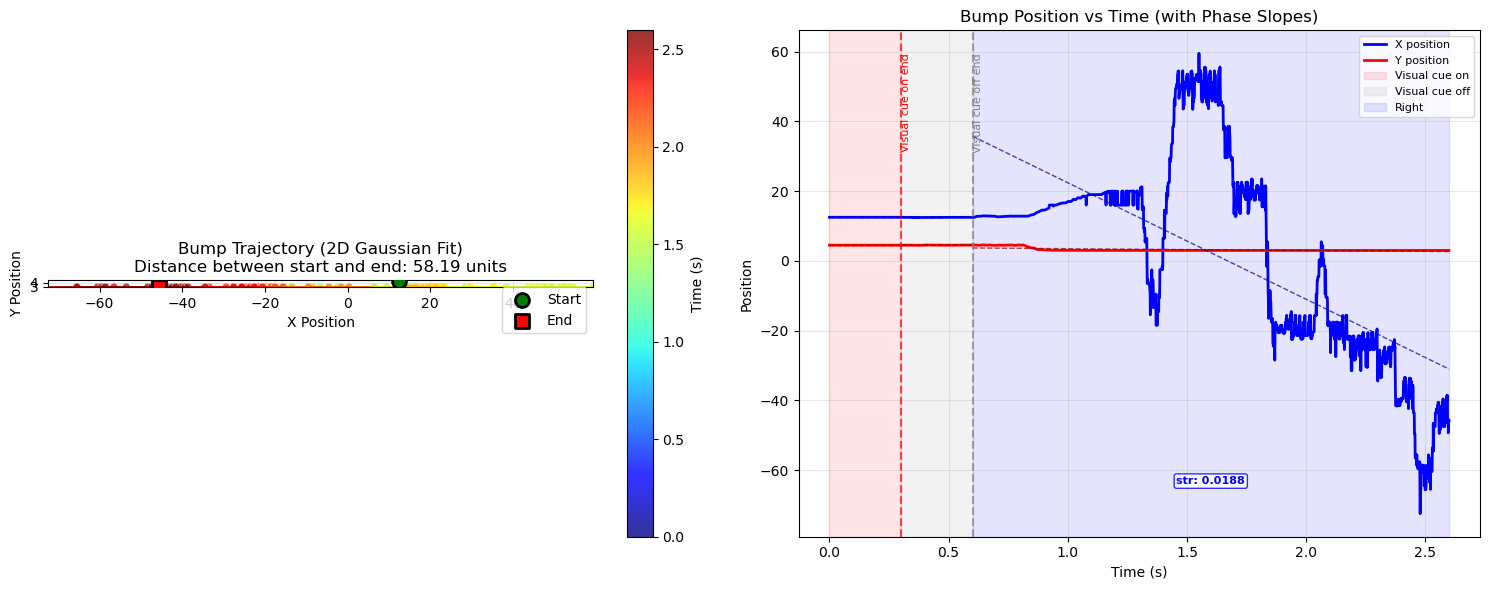

22:31:54 : 15 min 3.8 sec -> simulation end
22:31:55 : 15 min 24.5 sec -> simulation end
22:32:02 : 14 min 23.6 sec -> simulation end
22:32:03 : 14 min 31.5 sec -> simulation end
22:32:05 : 14 min 7.7 sec -> simulation end


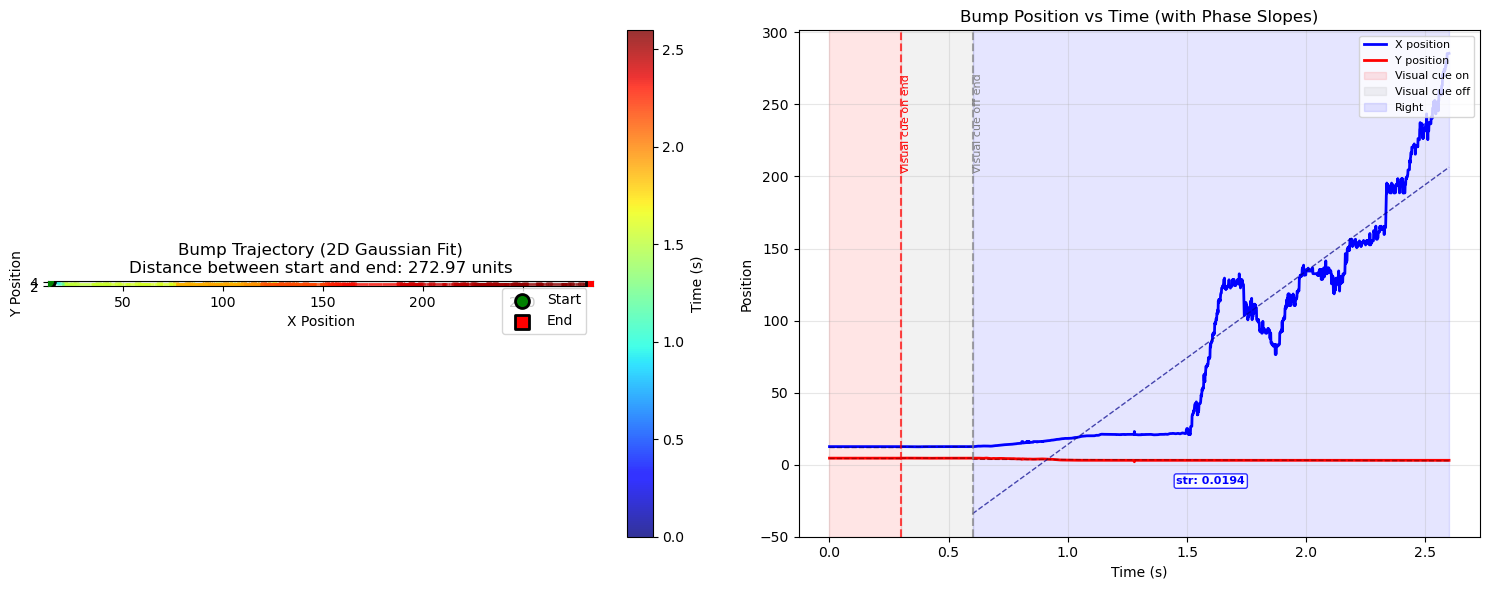

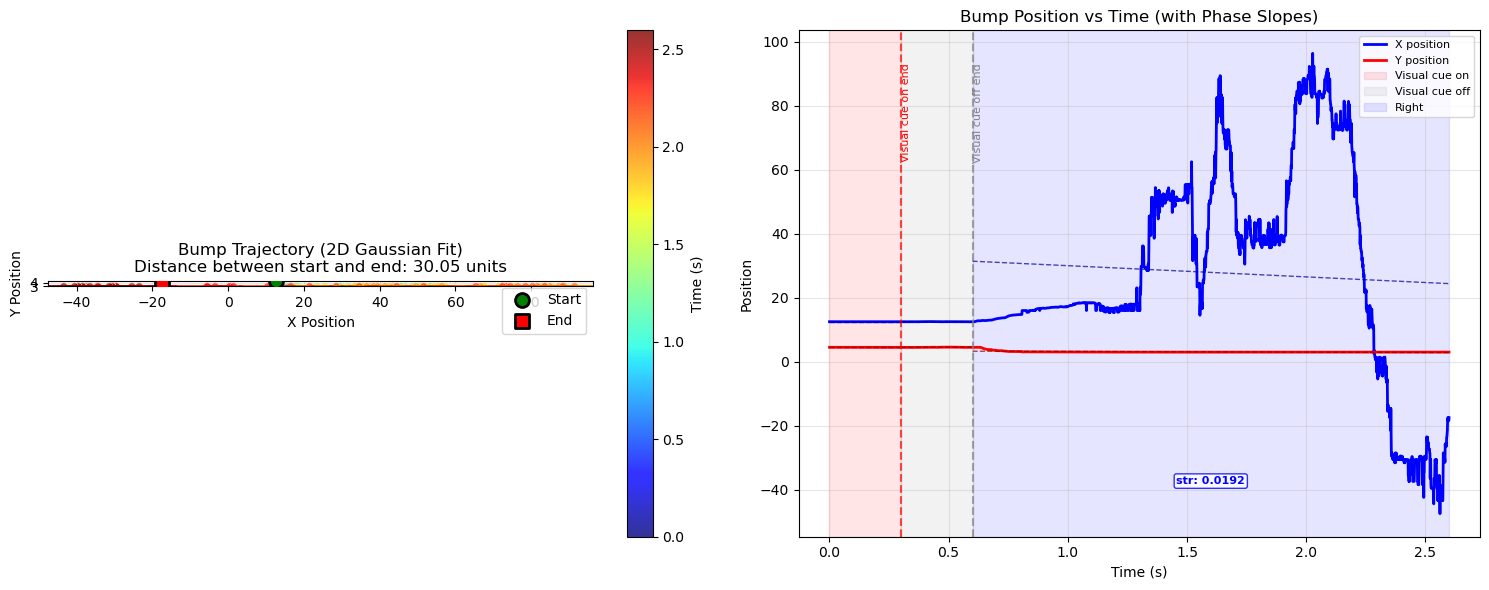

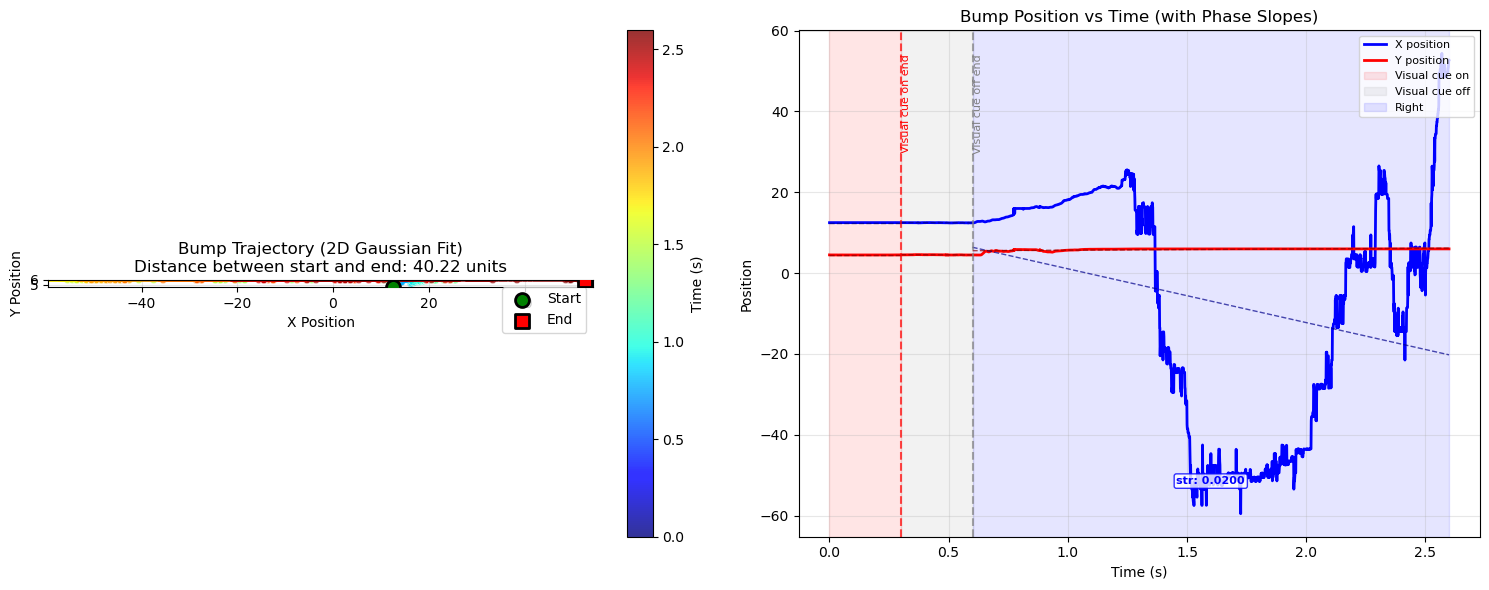

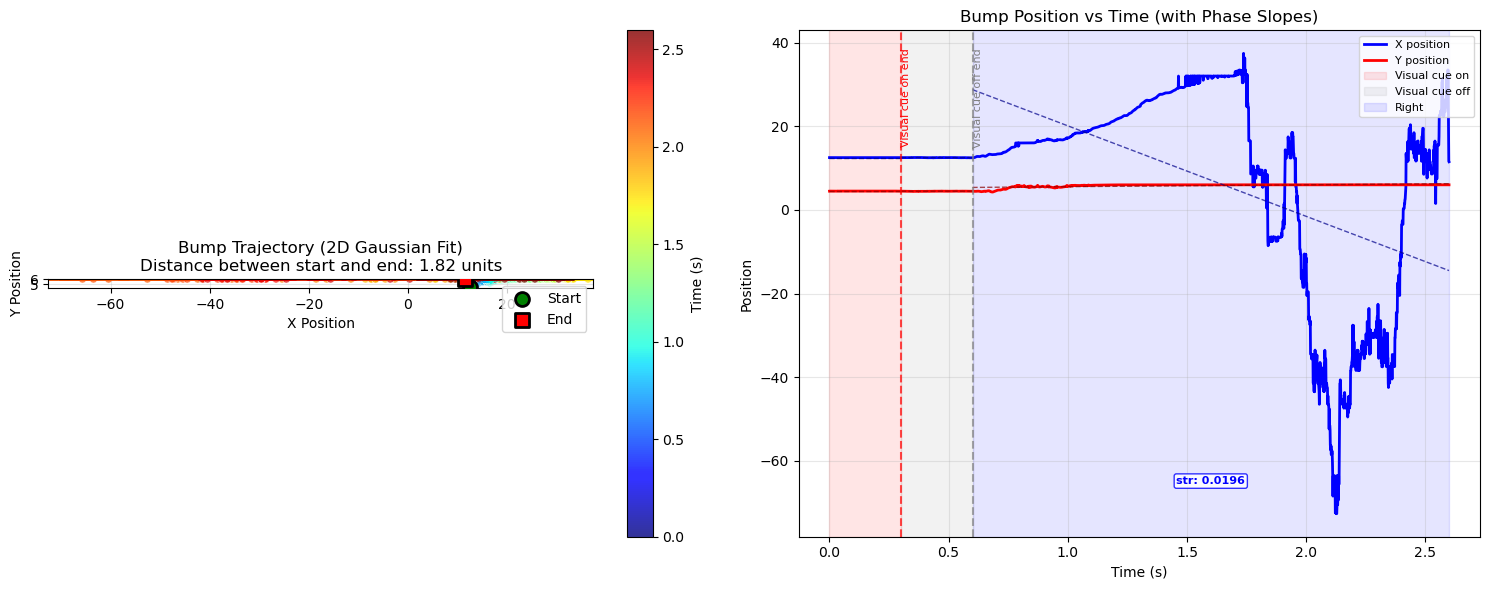

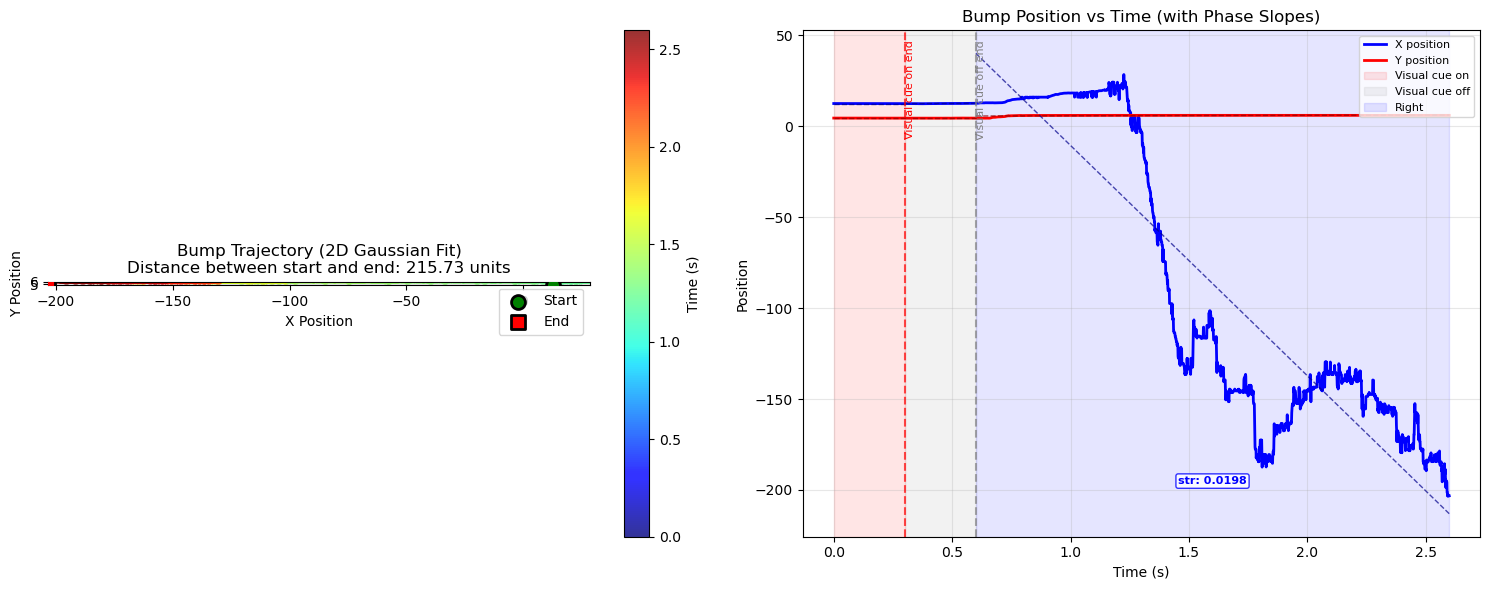

Running simulations: 100%|██████████| 30/30 [00:00<00:00, 459230.36it/s]


In [13]:
from tqdm import tqdm, trange
from multiprocessing import Pool
import multiprocessing as mp
import random

parameters = {
  "w_EE": 0.72,
  "w_EI": 0.143, # 0.143
  "w_IE": 0.76, # 0.74
  "w_II": 0.01, # 0.01
  "w_PP": 0.01,
  "w_EP": 0.013, # 0.012
  "w_PE": 0.71, # .709
  "sigma": 0.001,
}

events = [
        {'type': 'visual_cue_on', 'x': 2, 'y': 6, 'strength': 0.5, 'duration': 300*ms},
        {'type': 'visual_cue_off', 'duration': 300*ms},
        {'type': 'shift', 'direction': 'right', 'strength': 0.018, 'duration': 2000*ms},
    ]


def run_single_simulation(seed, shift_strength):
    """
    Run a single simulation with a given random seed
    
    Args:
        seed (int): Random seed for the simulation
    
    Returns:
        tuple: (speed, bump_positions) from the simulation
    """
    events[2]['strength'] = shift_strength
    t, fr, fr_penx, fr_peny = simulator(w_EE = parameters['w_EE'], # EB <-> EB
                    w_EI = parameters['w_EI'], # EPG -> R # 0.15
                    w_IE = parameters['w_IE'], # R -> EPG
                    w_II = parameters['w_II'], # R <-> R
                    w_PP = parameters['w_PP'], # PEN <-> PEN
                    w_EP = parameters['w_EP'], # EB -> PEN 
                    w_PE = parameters['w_PE'], # PEN -> EB
                    sigma = parameters['sigma'], # noise level
                    
                    events = events,
                    defaultclock_dt=0.1,
                    seed=seed)

    processed_data = process_data(fr)
    bp, fit_params = bump_position(processed_data)
    trajectory_results = analyze_trajectory(bp, fit_params, processed_data, events)
    direction = events[2]['direction'].capitalize() 
    speed = trajectory_results['phase_results'][direction]['speed']
    bump_pos = trajectory_results['bump_positions']
    return speed, bump_pos


def run_multiple_simulations(parameters, events, num_simulations=10, n_processes=None):
    """
    Run multiple simulations with different random seeds and collect results using parallel computation
    
    Args:
        parameters (dict): Parameters for the simulation
        events (list): List of events for the simulation
        num_simulations (int): Number of simulations to run
        n_processes (int): Number of processes to use. If None, uses all available CPUs
    
    Returns:
        tuple: (speeds, bump_positions) lists from all simulations
    """ 
    if n_processes is None:
        n_processes = mp.cpu_count()
    
    print(f"Running {num_simulations} simulations using {n_processes} processes")
    
    # Create list of seeds for each simulation
    seeds = list(range(num_simulations))
    shift_strengths = np.linspace(0.014, 0.02, num_simulations)
    
    # Run simulations in parallel
    with Pool(processes=n_processes) as pool:
        results = list(tqdm(
            pool.starmap(run_single_simulation, zip(seeds, shift_strengths)),
            total=num_simulations,
            desc="Running simulations"
        ))
    # Separate speeds and bump_positions
    speeds = [result[0] for result in results]
    bump_positions = [result[1] for result in results]
    
    return speeds, bump_positions

speeds, bump_positions = run_multiple_simulations(parameters, events, num_simulations=30, n_processes=25)

WARNING    /tmp/ipykernel_522223/666830727.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
 [py.warnings]


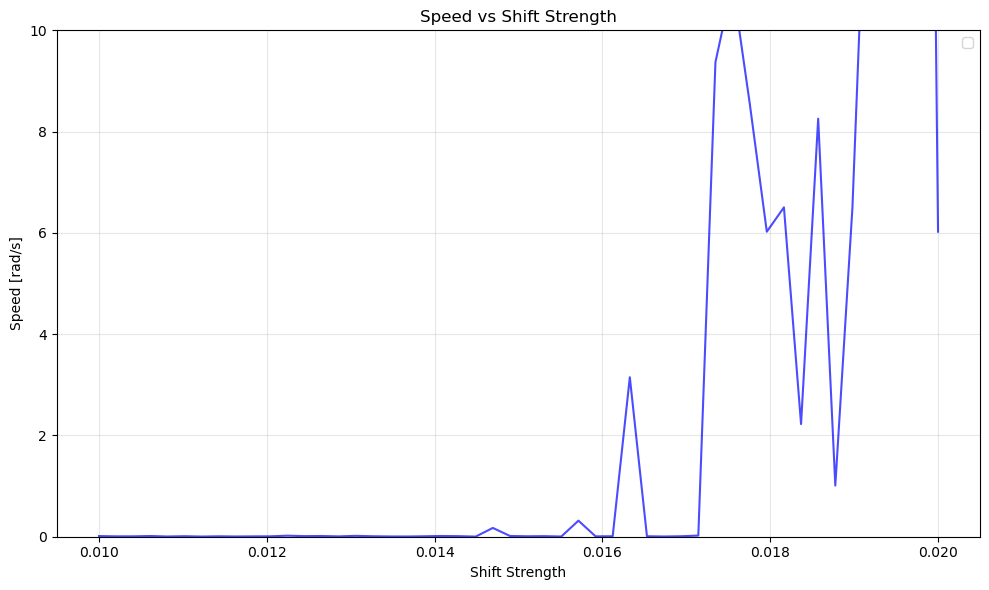

Correlation between shift strength and speed: 0.515


In [ ]:
# Calculate statistics for speeds
speeds_array = np.array(speeds) * 2 * np.pi / 16
speed_mean = np.mean(speeds_array)
speed_std = np.std(speeds_array)
speed_median = np.median(speeds_array)
speed_min = np.min(speeds_array)
speed_max = np.max(speeds_array)

# Plot speeds vs shift strengths
shift_strengths = np.linspace(0.01, 0.02, len(speeds))

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Scatter plot of speeds vs shift strengths
ax.plot(shift_strengths, speeds_array, alpha=0.7, color='blue')

# Add trend line
z = np.polyfit(shift_strengths, speeds_array * 2 * np.pi / 16, 1)
p = np.poly1d(z)

ax.set_xlabel('Shift Strength')
ax.set_ylabel('Speed [rad/s]')
ax.set_title('Speed vs Shift Strength')
ax.set_ylim(0, 10)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation
correlation = np.corrcoef(shift_strengths, speeds_array)[0, 1]
print(f"Correlation between shift strength and speed: {correlation:.3f}")


In [ ]:
print(speeds)

[0.03262922106040209, 0.019565342420502892, 0.020106805395050872, 0.036035678439230105, 0.011690877669692375, 0.02600761568875179, 0.008744428833209708, 0.02130818854610616, 0.011822664577543548, 0.018006080172216353, 0.020359598744081976, 0.05260803910907855, 0.03061921244790498, 0.03631657667887035, 0.017039642388858297, 0.0443540487083062, 0.02359869676002229, 0.013351968407532439, 0.010814415093885118, 0.02250128483359267, 0.037216801182009034, 0.02878217690306992, 0.006159282706313264, 0.44271338640411034, 0.03844569974004285, 0.022703026741574803, 0.028682157472363686, 0.010582780354661914, 0.8081268575380556, 0.018273251085269678, 0.024513282680614, 8.020628266334207, 0.023607521333028587, 0.011586017770008714, 0.023475859892226347, 0.05771223570289859, 23.863494329309763, 27.83332698733959, 21.8061783635991, 15.337793893184529, 16.5645810920197, 5.664136935812688, 21.02150277450213, 2.5716178091450055, 16.542545045115972, 38.67482500732053, 62.90590957787478, 182.06622568176982

In [ ]:
labels = ["right", "left", "up", "down"]
means =  [9.99, 9.75, 9.13, 8.75]
stds =   [0.67, 0.57, 1.98, 2.12]
medians =[10.20, 9.85, 10.00, 9.32]
mins =   [8.40, 8.54, 3.84, 4.15]
maxs =   [10.69, 10.49, 10.91, 11.23]

# Create box plot with statistics
import plotly.graph_objects as go

fig = go.Figure()

# Add box plots for each direction
for i, label in enumerate(labels):
    fig.add_trace(go.Box(
        y=[mins[i], medians[i] - stds[i]/2, medians[i], medians[i] + stds[i]/2, maxs[i]],
        name=label,
        # boxmean='sd',  # This creates dashed lines showing mean and standard deviation
        boxpoints='outliers',
        marker_color=['blue', 'green', 'red', 'orange'][i],
        showlegend=True
    ))
# Update layout
fig.update_layout(
    title='Speed Statistics Summary',
    xaxis_title='Direction',
    yaxis_title='Speed [rad/s]',
    width=800,
    height=500,
    showlegend=True,
    hovermode='x unified',
    yaxis=dict(gridcolor='lightgray', gridwidth=1),  # Grid lines (also dashed by default)
    plot_bgcolor='white'
)

fig.show()